# Shopper Archetypes: Testing the Universal-Pattern Assumption in Grocery Recommendation

**CSCE 676 — Data Mining and Analysis**
**Texas A&M University — Spring 2026**
**Author:** Ahad Hussain (UIN 535007416)


## 1. Introduction & Motivation

Every major online grocery platform — Instacart, DoorDash, Walmart — answers the same
question every time a customer opens the app: *when you add something to your cart,
what are you going to add next?* The industry answers this question by mining millions
of baskets for patterns — what people buy together, what you've bought before, when you
tend to shop — and turning those patterns into recommendations for everyone.

Baked into that approach is an assumption: **that the patterns are universal**. That
the association rules mined from all shoppers together are the rules that should drive
recommendations for each individual shopper. Whether that assumption holds is rarely
questioned in practice. If it's wrong — if shoppers of different types are actually
governed by fundamentally different rule sets — then every recommender built on a
single universal rule set is leaving a large amount of signal on the table.

This project tests that assumption directly. Using the **Instacart Online Grocery
Shopping Dataset 2017** (~3.4M orders, ~32M order-product lines, ~49K products, ~206K
users), we ask: *when you mine the same baskets four different ways, how much do the
discovered patterns actually change?*

1. **RQ1 — Support calibration.** Before we can compare rule sets across lenses,
   we need a reliable support threshold. What threshold yields statistically reliable
   rules without collapsing to trivial staples?
2. **RQ2 — Temporal context.** Does splitting shoppers by *when* they shop
   (weekend/weekday, time of day) change the discovered rule sets? This is one of the
   three industry-standard personalization levers.
3. **RQ3 — Sequential context.** Does treating each user's orders as a *sequence*
   rather than a bag reveal inter-order flows that bag-of-items mining cannot?
   This is the third industry lever: order history. *(Beyond-course technique.)*
4. **RQ4 — Shopper type.** If we let the data sort customers into archetypes first
   and mine each archetype's baskets separately, does the rule set change?
   This is the lens the industry does *not* use as a primary recommendation signal.

The unifying measurement is **how much each lens changes the discovered patterns**,
quantified as 1 − Jaccard similarity of the per-segment rule sets. A lens that changes
nothing (Jaccard ≈ 1) adds no recommendation signal. A lens that changes everything
(Jaccard ≈ 0) implies fundamentally different rule sets per segment and a universal
recommender is leaving signal on the table.

**The headline finding:** the universal-pattern assumption breaks when you split by
shopper archetype. Temporal context lenses change a small fraction of the patterns;
shopper archetype changes almost all of them.


### 1.1 RQ-to-Method Mapping

| RQ  | What it tests                                                    | Algorithm            | Course / Beyond       | Primary metric                                       |
|-----|------------------------------------------------------------------|----------------------|-----------------------|------------------------------------------------------|
| RQ1 | Rule-mining calibration (support sweet spot)                     | FP-Growth            | Course                | Rule count, lift distribution, runtime               |
| RQ2 | Does *when* you shop change the rules? (time-context lens)       | FP-Growth / segment  | Course                | 1 − Jaccard of rule sets; segment-exclusive rules    |
| RQ3 | Does *order history* change the rules? (sequence-context lens)   | PrefixSpan           | **Beyond course**     | Sequential-only patterns; shuffle baseline           |
| RQ4 | Does *who shops* change the rules? (shopper-archetype lens)      | NMF + FP-Growth      | Course (clustering)   | 1 − Jaccard of per-archetype rule sets               |

The three context lenses (RQ2, RQ3) plus threshold calibration (RQ1) span what grocery
recommenders already do today. RQ4 tests the lens they don't: let the data decide who
the customer types are, then mine the rules per type.


### 1.2 Resources & Collaboration Declaration

On my honor, I declare the following resources used for this project:

**1. Collaborators:**
- None. This is an individual project.

**2. Web Sources:**
- [Instacart Market Basket Analysis dataset on Kaggle](https://www.kaggle.com/c/instacart-market-basket-analysis) — the raw 2017 dataset (orders, products, aisles, departments, order_products).
- [`mlxtend` frequent pattern documentation](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/) — for FP-Growth API usage and the `apriori`/`fpgrowth` interface.
- [`prefixspan` PyPI docs](https://pypi.org/project/prefixspan/) — for PrefixSpan API and minimum-support parameter conventions.
- [scikit-learn clustering user guide](https://scikit-learn.org/stable/modules/clustering.html) — for K-Means, GMM, and silhouette scoring.
- [scikit-learn `NMF` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) — for NMF initialization, `n_components` semantics, and transform / reconstruction error usage.
- [pandas Parquet I/O reference](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_parquet.html) — for the zstd-compressed Parquet conversion pipeline.

**3. AI Tools:**
- **Anthropic Claude:** Used throughout the project as an iteration and refinement partner. I wrote the code myself; Claude helped me refactor, debug, and tighten it — for example, suggesting more efficient pandas operations, catching edge cases in the Jaccard comparisons, and helping debug the sparse-matrix FP-Growth pipeline when I ran into memory issues. Claude also helped draft and iterate on the markdown cells across §1, §7, and §8, refine the RQ-to-method table layout, and shape the recommendation-systems narrative tying all four RQs together. Claude additionally scaffolded the unit test skeleton in §9 and helped upgrade the RQ4 clustering approach (the three-algorithm comparison and NMF decomposition) after the baseline K-Means result was weak. All analytical decisions — which algorithms to run, how to preprocess, what the Jaccard numbers mean, and what conclusions to draw — are my own. All numerical results come from the code cells as executed on my environment.
- **OpenAI ChatGPT:** Used as a second-opinion check on the framing of the cross-RQ synthesis (§7) and on whether the universal-pattern-assumption framing was defensible given the actual results. No code or numerical output from ChatGPT is used in this notebook.

All code in this notebook was written and executed by me. All numerical results, Jaccard values, rule counts, clustering silhouettes, and archetype profiles come from the code cells as run on my environment. Library imports are standard PyPI packages (see `requirements.txt`).


## 2. Setup & Data Loading

We load the full `order_products__prior` file (~32M rows) and merge it with product, aisle,
and department metadata. Two basket representations are then built:

1. **Department-level baskets** (21 categories) — small enough to run on the **full**
   ~3.2M-order dataset as a dense boolean matrix.
2. **Product-level baskets** (~49K products) — far too large for a dense matrix
   (500K × 49K ≈ 24 GB), so we use `mlxtend`'s **sparse** `TransactionEncoder` on a
   500K-order random sample.

We also build two derived artifacts used in later sections:

- **User × department frequency matrix** (for RQ4 clustering)
- **Per-user dominant-department sequences** (for RQ3 PrefixSpan)


In [6]:
# Core imports
import os
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

def md(text): display(Markdown(text))
def md_table(df, title=None, n=None):
    if title: display(Markdown(f"**{title}**"))
    display(df.head(n) if n else df)

# --- Progress logging helpers -------------------------------------------
# Long-running cells can be silent for many minutes in Colab. `log()` emits
# timestamped lines with flush=True so Colab's stdout buffer shows progress
# live, and `Timer` pairs a START / DONE around any block so the user can
# see which step is currently executing and how long each one took.
def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)

class Timer:
    """Context manager that logs entry + exit with elapsed seconds."""
    def __init__(self, label):
        self.label = label
    def __enter__(self):
        self.t0 = time.time()
        log(f"START {self.label}")
        return self
    def __exit__(self, *exc):
        log(f"DONE  {self.label} in {time.time() - self.t0:.1f}s")

DATA_DIR = Path("data/instacart")
assert DATA_DIR.exists(), f"Data directory missing: {DATA_DIR.resolve()}"
print("Data dir:", DATA_DIR.resolve())


Data dir: /content/data/instacart


In [7]:
# --- Config / scale knobs -----------------------------------------------
# Set FAST_MODE=True to run everything on a small sample (~5 min end-to-end).
# Set FAST_MODE=False for the full deliverable run.
FAST_MODE = False

PRODUCT_SAMPLE_N = 100_000 if FAST_MODE else 500_000   # orders for product-level FP-Growth
PREFIXSPAN_USER_N = 20_000 if FAST_MODE else 50_000    # users for PrefixSpan
RQ1_THRESHOLDS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
RQ2_SUPPORT = 0.01
RQ4_K_RANGE = range(2, 9)

# --- Parallelism --------------------------------------------------------
# Independent loops in this notebook (RQ1 threshold sweep, RQ4 KMeans
# k-sweep, per-cluster FP-Growth) are dispatched with joblib so they use
# every available core. N_JOBS_HEAVY caps parallelism for the product-level
# sweep because the 500K x 46K sparse matrix is pickled once per worker and
# low-support runs allocate several GB each.
N_JOBS = max(1, os.cpu_count() or 1)
N_JOBS_HEAVY = min(N_JOBS, 2)

print(f"FAST_MODE        = {FAST_MODE}")
print(f"N_JOBS           = {N_JOBS} (available cores: {os.cpu_count()})")
print(f"N_JOBS_HEAVY     = {N_JOBS_HEAVY}  (product-level sweep)")
print(f"Product sample   = {PRODUCT_SAMPLE_N:,} orders")
print(f"PrefixSpan users = {PREFIXSPAN_USER_N:,}")


FAST_MODE        = False
N_JOBS           = 8 (available cores: 8)
N_JOBS_HEAVY     = 2  (product-level sweep)
Product sample   = 500,000 orders
PrefixSpan users = 50,000


In [8]:
# --- Load raw tables ----------------------------------------------------
with Timer("loading parquet tables"):
    orders = pd.read_parquet(DATA_DIR / "orders.parquet")
    order_products_prior = pd.read_parquet(DATA_DIR / "order_products__prior.parquet")
    products = pd.read_parquet(DATA_DIR / "products.parquet")
    aisles = pd.read_parquet(DATA_DIR / "aisles.parquet")
    departments = pd.read_parquet(DATA_DIR / "departments.parquet")
print(f"  orders:                {len(orders):>12,}")
print(f"  order_products_prior:  {len(order_products_prior):>12,}")
print(f"  products:              {len(products):>12,}")
print(f"  aisles:                {len(aisles):>12,}")
print(f"  departments:           {len(departments):>12,}")


[23:31:13] START loading parquet tables
[23:31:14] DONE  loading parquet tables in 0.8s
  orders:                   3,421,083
  order_products_prior:    32,434,489
  products:                    49,688
  aisles:                         134
  departments:                     21


In [9]:
# --- Enrich products with aisle and department names -------------------
products_enriched = (
    products
      .merge(aisles, on="aisle_id")
      .merge(departments, on="department_id")
)
products_enriched.head(3)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages


In [10]:
# --- Merge order lines with product metadata + order temporal features --
with Timer("merging order_lines with product + order metadata"):
    op = order_products_prior.merge(
        products_enriched[["product_id", "product_name", "aisle", "department"]],
        on="product_id"
    )
    op = op.merge(
        orders[["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day"]],
        on="order_id"
    )
print(f"  op shape: {op.shape}")
op.head(3)


[23:31:14] START merging order_lines with product + order metadata
[23:31:27] DONE  merging order_lines with product + order metadata in 13.2s
  op shape: (32434489, 11)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle,department,user_id,order_number,order_dow,order_hour_of_day
0,2,33120,1,1,Organic Egg Whites,eggs,dairy eggs,202279,3,5,9
1,2,28985,2,1,Michigan Organic Kale,fresh vegetables,produce,202279,3,5,9
2,2,9327,3,0,Garlic Powder,spices seasonings,pantry,202279,3,5,9


### 2.1 Build Department-Level Baskets (Full Dataset)

Department-level baskets are small enough to run on the full ~3.2M-order prior dataset.


In [11]:
# Fast path for building dept baskets:
# the previous version did `groupby.apply(lambda s: sorted(set(s)))` which pays
# Python-lambda overhead once per group (3.2M groups => ~40s). We instead
# `drop_duplicates` so each (order_id, department) pair appears once, then do
# a single `.agg(list)` which pandas can execute in Cython.
with Timer("building department-level baskets (full ~3.2M orders)"):
    dept_pairs = op[["order_id", "department"]].drop_duplicates()
    log(f"  unique (order_id, department) pairs: {len(dept_pairs):,}")
    dept_baskets_series = (
        dept_pairs.sort_values(["order_id", "department"])
                  .groupby("order_id", sort=False)["department"]
                  .agg(list)
    )
    dept_baskets = dept_baskets_series.tolist()
    # order_id -> basket dict for O(1) lookup by RQ2/RQ4 segmentation.
    order_to_dept_basket = dept_baskets_series.to_dict()
    log(f"  built {len(dept_baskets):,} dept baskets")

with Timer("encoding dept basket matrix"):
    te_dept = TransactionEncoder()
    dept_basket_matrix = te_dept.fit_transform(dept_baskets)
    # Index by order_id so downstream segmentation / clustering can do
    # `dept_basket_df.loc[order_ids]` instead of rebuilding from `op` each call.
    dept_basket_df = pd.DataFrame(
        dept_basket_matrix, columns=te_dept.columns_,
        index=dept_baskets_series.index,
    )
    dept_basket_df.index.name = "order_id"
    log(f"  matrix: {dept_basket_df.shape} "
        f"(~{dept_basket_df.memory_usage(deep=True).sum()/1e6:.0f} MB)")


[23:31:27] START building department-level baskets (full ~3.2M orders)
[23:31:35]   unique (order_id, department) pairs: 15,226,198
[23:32:27]   built 3,214,874 dept baskets
[23:32:27] DONE  building department-level baskets (full ~3.2M orders) in 59.4s
[23:32:27] START encoding dept basket matrix
[23:32:30]   matrix: (3214874, 21) (~80 MB)
[23:32:30] DONE  encoding dept basket matrix in 3.8s


### 2.2 Build Product-Level Baskets (500K-order Sample, Sparse)

Dense encoding of 500K × 49K booleans would require ~24 GB. We use `mlxtend`'s
`sparse=True` path, which stores baskets in SciPy CSR format (roughly one byte per
item-in-basket rather than one per cell).


In [12]:
rng = np.random.default_rng(42)
sample_order_ids = rng.choice(
    op["order_id"].unique(), size=PRODUCT_SAMPLE_N, replace=False
)
sample_order_ids_set = set(sample_order_ids.tolist())
op_sample = op[op["order_id"].isin(sample_order_ids_set)]
log(f"Sampled {PRODUCT_SAMPLE_N:,} orders, {len(op_sample):,} order-lines")

# Same drop_duplicates + agg(list) pattern as the dept build.
with Timer("building product-level baskets (sample)"):
    prod_pairs = op_sample[["order_id", "product_name"]].drop_duplicates()
    product_baskets_series = (
        prod_pairs.sort_values(["order_id", "product_name"])
                  .groupby("order_id", sort=False)["product_name"]
                  .agg(list)
    )
    product_baskets = product_baskets_series.tolist()

with Timer("encoding product basket matrix (sparse)"):
    te_prod = TransactionEncoder()
    product_basket_sparse = te_prod.fit(product_baskets).transform(
        product_baskets, sparse=True
    )
    product_basket_df = pd.DataFrame.sparse.from_spmatrix(
        product_basket_sparse, columns=te_prod.columns_
    )
    log(f"  matrix: {product_basket_df.shape}")


[23:32:35] Sampled 500,000 orders, 5,042,362 order-lines
[23:32:35] START building product-level baskets (sample)
[23:32:47] DONE  building product-level baskets (sample) in 12.4s
[23:32:47] START encoding product basket matrix (sparse)
[23:32:50]   matrix: (500000, 46044)
[23:32:50] DONE  encoding product basket matrix (sparse) in 3.0s


### 2.3 Temporal Metadata

We derive `is_weekend` and a 3-bin `time_segment` from the order-level temporal fields.
Instacart codes `order_dow=0` as Sunday and `order_dow=6` as Saturday, so the weekend mask
is `dow in {0, 6}`.


In [13]:
orders_meta = orders.copy()
orders_meta["is_weekend"] = orders_meta["order_dow"].isin([0, 6])
orders_meta["time_segment"] = pd.cut(
    orders_meta["order_hour_of_day"],
    bins=[-1, 11, 16, 23],
    labels=["morning", "afternoon", "evening"],
)
orders_meta[["order_id", "order_dow", "order_hour_of_day",
             "is_weekend", "time_segment"]].head(3)


,order_id,order_dow,order_hour_of_day,is_weekend,time_segment
0,2539329,2,8,False,morning
1,2398795,3,7,False,morning
2,473747,3,12,False,afternoon


### 2.4 User × Department Frequency Matrix (for RQ4)

For each user, we compute the fraction of their orders containing each department. This
is a compact ~206K × 21 matrix that K-Means can cluster almost instantly.


In [14]:
# The previous version built an intermediate Series of Python `set` objects
# and then `.explode()`'d it. That path allocates 32M throwaway Python
# objects. The direct groupby below drops all of that and runs ~5x faster.
with Timer("building user x department frequency matrix"):
    uod = op[["user_id", "order_id", "department"]].drop_duplicates()
    log(f"  unique (user, order, dept) triples: {len(uod):,}")

    user_total_orders = uod.groupby("user_id")["order_id"].nunique()
    log(f"  users: {len(user_total_orders):,}")

    user_dept_counts = (
        uod.groupby(["user_id", "department"])
           .size()
           .unstack(fill_value=0)
    )
    user_dept_freq = user_dept_counts.div(user_total_orders, axis=0).fillna(0.0)
    log(f"  user_dept_freq: {user_dept_freq.shape}")
user_dept_freq.head(3)


[23:32:51] START building user x department frequency matrix
[23:33:00]   unique (user, order, dept) triples: 15,226,198
[23:33:01]   users: 206,209
[23:33:05]   user_dept_freq: (206209, 21)
[23:33:05] DONE  building user x department frequency matrix in 14.2s


department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,...,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.000000,1.000000,0.300000,0.0,0.000000,0.900000,0.000000,0.000000,...,0.200000,0.000000,0.000000,0.0,0.0,0.100000,0.000000,0.0,0.2,1.000000
2,0.0,0.0,0.142857,0.428571,0.071429,0.0,0.071429,0.785714,0.714286,0.000000,...,0.000000,0.214286,0.071429,0.0,0.0,0.642857,0.071429,0.0,1.0,0.928571
3,0.0,0.0,0.000000,0.250000,0.000000,0.0,0.000000,0.916667,0.166667,0.333333,...,0.083333,0.000000,0.000000,0.0,0.0,0.333333,0.000000,0.0,1.0,0.583333


### 2.5 Per-User Dominant-Department Sequences (for RQ3)

Each user's order history becomes a list of dominant departments, one per order,
in the order they occurred. The dominant department is whichever contributes the most
items to that basket. This collapses each order to a single token so PrefixSpan's event
alphabet has just 21 symbols — avoiding the combinatorial explosion that would come from
treating each order as a full department set.


In [15]:
with Timer("building per-user dominant-department sequences"):
    order_dept_counts = (
        op.groupby(["user_id", "order_number", "order_id", "department"])
          .size()
          .reset_index(name="n")
    )
    dominant = (
        order_dept_counts
          .sort_values(["user_id", "order_number", "n"],
                       ascending=[True, True, False])
          .drop_duplicates(["user_id", "order_number"])
          [["user_id", "order_number", "department"]]
          .sort_values(["user_id", "order_number"])
    )
    user_sequences = (
        dominant.groupby("user_id")["department"].apply(list)
    )
    seq_lens = user_sequences.map(len)
    log(f"  users with sequences: {len(user_sequences):,}")
    log(f"  median sequence length: {seq_lens.median():.0f}, max: {seq_lens.max()}")


[23:33:05] START building per-user dominant-department sequences
[23:33:28]   users with sequences: 206,209
[23:33:28]   median sequence length: 9, max: 99
[23:33:28] DONE  building per-user dominant-department sequences in 22.8s


### 2.6 User × Aisle Frequency + Behavioral Features *(for RQ4 upgrade)*

The baseline RQ4 matrix (§2.4) has 21 department dimensions — too coarse to separate
~206K users. This section builds the richer representation used in §6.5–§6.7:

1. **`user_aisle_freq`** — ~206K × 134 matrix; each cell is the fraction of a user's
   orders containing at least one item from that aisle. Aisles like
   *"fresh herbs"*, *"baby food formula"*, *"energy bars"* carve purchase mix much
   finer than departments like *"snacks"* or *"dairy eggs"*.
2. **`behavioral`** — 6 per-user features orthogonal to purchase mix: `n_orders`,
   `median_basket_size`, `reorder_rate`, `median_days_between_orders`,
   `weekend_fraction`, `median_hour_of_day`. These capture *how/when* someone shops,
   which department-only features conflated with *what* they buy.

We then standardize each block (z-score) and concatenate into `X_enriched`.

In [16]:
# --- User x aisle frequency matrix (206K x 134) --------------------------
with Timer("building user x aisle frequency matrix"):
    uoa = op[["user_id", "order_id", "aisle"]].drop_duplicates()
    log(f"  unique (user, order, aisle) triples: {len(uoa):,}")
    user_aisle_counts = (
        uoa.groupby(["user_id", "aisle"]).size().unstack(fill_value=0)
    )
    # user_total_orders is already computed in §2.4
    user_aisle_freq = (
        user_aisle_counts.div(user_total_orders, axis=0)
                         .fillna(0.0)
                         .astype("float32")
    )
    log(f"  user_aisle_freq: {user_aisle_freq.shape}")
    nz = (user_aisle_freq > 0).sum(axis=1)
    log(f"  median nonzero aisles/user: {nz.median():.0f}, mean: {nz.mean():.1f}")

# --- Behavioral features -------------------------------------------------
with Timer("building per-user behavioral features"):
    order_user = orders.set_index("order_id")["user_id"]
    basket_sizes = order_products_prior.groupby("order_id").size()
    basket_with_user = pd.DataFrame({
        "basket": basket_sizes,
        "user_id": order_user.reindex(basket_sizes.index).values,
    })
    n_orders_beh = user_total_orders.rename("n_orders")
    median_basket_size = basket_with_user.groupby("user_id")["basket"].median().rename("median_basket_size")
    reorder_rate = (
        order_products_prior.assign(
            user_id=order_user.reindex(order_products_prior["order_id"]).values
        )
        .groupby("user_id")["reordered"].mean().rename("reorder_rate")
    )
    median_days = (
        orders.dropna(subset=["days_since_prior_order"])
              .groupby("user_id")["days_since_prior_order"].median()
              .rename("median_days_between_orders")
    )
    weekend_fraction = (
        orders.assign(_w=orders["order_dow"].isin([0, 6]).astype(int))
              .groupby("user_id")["_w"].mean().rename("weekend_fraction")
    )
    median_hour = (
        orders.groupby("user_id")["order_hour_of_day"].median().rename("median_hour_of_day")
    )
    behavioral = pd.concat(
        [n_orders_beh, median_basket_size, reorder_rate, median_days,
         weekend_fraction, median_hour], axis=1
    ).astype("float32")
    behavioral = behavioral.reindex(user_aisle_freq.index).fillna(
        behavioral.median(numeric_only=True)
    )
    log(f"  behavioral: {behavioral.shape}")

# --- Enriched standardized feature matrix (for K-Means, GMM) -------------
with Timer("standardizing + concatenating enriched features"):
    _scaler_a = StandardScaler().fit(user_aisle_freq.values)
    _scaler_b = StandardScaler().fit(behavioral.values)
    X_enriched = np.concatenate(
        [_scaler_a.transform(user_aisle_freq.values),
         _scaler_b.transform(behavioral.values)],
        axis=1,
    ).astype("float32")
    log(f"  X_enriched: {X_enriched.shape}  ({X_enriched.nbytes/1e6:.0f} MB)")
behavioral.describe().round(2)

[23:33:28] START building user x aisle frequency matrix
[23:33:38]   unique (user, order, aisle) triples: 23,338,453
[23:33:45]   user_aisle_freq: (206209, 134)
[23:33:45]   median nonzero aisles/user: 25, mean: 27.8
[23:33:45] DONE  building user x aisle frequency matrix in 17.6s
[23:33:45] START building per-user behavioral features
[23:33:49]   behavioral: (206209, 6)
[23:33:49] DONE  building per-user behavioral features in 4.3s
[23:33:49] START standardizing + concatenating enriched features
[23:33:50]   X_enriched: (206209, 140)  (115 MB)
[23:33:50] DONE  standardizing + concatenating enriched features in 0.4s


,n_orders,median_basket_size,reorder_rate,median_days_between_orders,weekend_fraction,median_hour_of_day
count,206209.00,206209.00,206209.00,206209.00,206209.00,206209.00
mean,15.59,9.53,0.43,15.15,0.32,13.59
std,16.66,6.02,0.21,8.90,0.24,2.55
min,3.00,1.00,0.00,0.00,0.00,0.00
25%,5.00,5.00,0.27,7.00,0.14,12.00
50%,9.00,8.00,0.43,13.00,0.29,13.50
75%,19.00,12.50,0.60,22.50,0.50,15.00
max,99.00,73.50,0.99,30.00,1.00,23.00


## 3. RQ1 — Support Threshold Calibration

> *Before we compare rule sets across lenses, we need to know what support threshold
> produces statistically reliable rules without collapsing to trivial staples.*

RQ1 is the calibration step. Everything downstream (RQ2, RQ4) mines rule sets at a
fixed support threshold and measures how much the rules change across segments. If
we pick the threshold too high, we only see obvious staples and every segment looks
identical. If we pick it too low, we drown in noise. The goal here is to find the
threshold where lens comparisons are most informative.

We sweep FP-Growth across six minimum-support thresholds at two granularities:

- **Department-level** on the **full** ~3.2M-order dataset (21 items)
- **Product-level** on a **500K-order sample** (~49K items)

For each run we record frequent itemsets, rule count (lift > 1), lift and confidence
distributions, item diversity, and runtime. The sweet spot we pick here gets reused
throughout RQ2 and RQ4, so every lens comparison is measured on the same foundation.


In [17]:
# mlxtend's pure-Python FP-Growth is too slow on the full 3.2M dept baskets
# (hangs for 10+ minutes at min_support=0.001 even with max_len=4). PyFIM is a
# C implementation that finishes the same work in seconds. We wrap it in an
# adapter that returns the mlxtend `[support, itemsets]` shape so downstream
# `association_rules(...)` calls work unchanged.
try:
    from fim import fpgrowth as _fim_fpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfim"])
    from fim import fpgrowth as _fim_fpgrowth


def fpgrowth_fast(baskets, min_support, max_len=None):
    """Run C-backed FP-Growth on a list-of-lists of items.

    Returns a DataFrame with `support` (float in [0,1]) and `itemsets`
    (frozenset) columns -- the same shape mlxtend's fpgrowth produces
    with `use_colnames=True`, so `association_rules` accepts it directly.
    """
    n = len(baskets)
    if n == 0:
        return pd.DataFrame(columns=["support", "itemsets"])
    # PyFIM: `supp` is percent (0-100), so supp=min_support*100 converts our
    # 0-1 threshold into PyFIM's expected unit. `target="s"` = all frequent
    # sets (not just closed/maximal). `report="a"` returns (itemset,
    # absolute_count) so `c / n` gives the correct relative support.
    # IMPORTANT: do NOT use report="S" -- that returns support as a
    # PERCENTAGE, which combined with `c / n` under-reports support by ~100x
    # and inflates downstream lift by the same factor.
    kwargs = dict(supp=min_support * 100, zmin=1, target="s", report="a")
    if max_len is not None:
        kwargs["zmax"] = max_len
    raw = _fim_fpgrowth(baskets, **kwargs)
    if not raw:
        return pd.DataFrame(columns=["support", "itemsets"])
    return pd.DataFrame(
        [{"support": c / n, "itemsets": frozenset(its)} for its, c in raw],
        columns=["support", "itemsets"],
    )


def _fpgrowth_one(baskets, sup, min_lift=1.0, max_len=None):
    """One (support, lift) evaluation on a list-of-lists of baskets."""
    t0 = time.time()
    fi = fpgrowth_fast(baskets, sup, max_len=max_len)
    fi_time = time.time() - t0
    if len(fi) == 0:
        return {
            "min_support": sup, "n_itemsets": 0, "n_rules": 0,
            "median_lift": np.nan, "median_conf": np.nan,
            "max_itemset_size": 0, "item_diversity": 0, "runtime_s": fi_time,
        }
    rules = association_rules(fi, metric="lift", min_threshold=min_lift)
    items = set()
    for a, b in zip(rules["antecedents"], rules["consequents"]):
        items.update(a); items.update(b)
    return {
        "min_support": sup,
        "n_itemsets": len(fi),
        "n_rules": len(rules),
        "median_lift": rules["lift"].median() if len(rules) else np.nan,
        "median_conf": rules["confidence"].median() if len(rules) else np.nan,
        "max_itemset_size": fi["itemsets"].map(len).max(),
        "item_diversity": len(items),
        "runtime_s": fi_time,
    }


def fpgrowth_sweep(baskets, thresholds, label="sweep",
                   n_jobs=1, min_lift=1.0, max_len=None):
    """Evaluate FP-Growth at each min_support over a list of baskets.

    PyFIM is already C-backed and each threshold runs in seconds, so we keep
    n_jobs=1 by default -- joblib's pickling overhead would dominate the work.
    """
    log(f"{label}: {len(thresholds)} thresholds on {n_jobs} worker(s)"
        + (f", max_len={max_len}" if max_len else ""))
    t0 = time.time()
    if n_jobs == 1:
        rows = []
        for sup in tqdm(thresholds, desc=label):
            t1 = time.time()
            log(f"  min_support={sup} ...")
            rows.append(_fpgrowth_one(baskets, sup, min_lift, max_len))
            log(f"  min_support={sup} done in {time.time() - t1:.1f}s")
    else:
        rows = Parallel(n_jobs=n_jobs, backend="loky", verbose=5)(
            delayed(_fpgrowth_one)(baskets, sup, min_lift, max_len)
            for sup in thresholds
        )
    log(f"{label}: done in {time.time() - t0:.1f}s")
    return pd.DataFrame(rows).sort_values("min_support").reset_index(drop=True)


### 3.1 Department-Level Sweep (Full Dataset)

In [18]:
rq1_dept_sweep = fpgrowth_sweep(
    dept_baskets, RQ1_THRESHOLDS, label="RQ1 dept sweep"
)
rq1_dept_sweep


[23:34:10] RQ1 dept sweep: 6 thresholds on 1 worker(s)


RQ1 dept sweep:   0%|          | 0/6 [00:00<?, ?it/s]

[23:34:10]   min_support=0.001 ...
[23:34:39]   min_support=0.001 done in 28.7s
[23:34:39]   min_support=0.005 ...
[23:34:45]   min_support=0.005 done in 6.0s
[23:34:45]   min_support=0.01 ...
[23:34:49]   min_support=0.01 done in 4.1s
[23:34:49]   min_support=0.02 ...
[23:34:53]   min_support=0.02 done in 3.8s
[23:34:53]   min_support=0.05 ...
[23:34:57]   min_support=0.05 done in 3.6s
[23:34:57]   min_support=0.1 ...
[23:35:00]   min_support=0.1 done in 3.5s
[23:35:00] RQ1 dept sweep: done in 49.8s


,min_support,n_itemsets,n_rules,median_lift,median_conf,max_itemset_size,item_diversity,runtime_s
0,0.001,24439,2876408,3.929715,0.100037,11,21,3.766532
1,0.005,6180,299718,2.607511,0.164734,9,21,3.626137
2,0.010,2964,90948,2.175136,0.203463,8,19,3.678074
3,0.020,1262,23022,1.822954,0.255607,7,16,3.660853
4,0.050,336,2820,1.460180,0.341940,5,15,3.618163
5,0.100,102,442,1.254869,0.433022,4,13,3.520151


### 3.2 Product-Level Sweep (500K-Order Sample)

In [19]:
# Product-level sweep. PyFIM consumes list-of-lists directly -- no sparse
# encoding needed -- and is fast enough to run serially.
rq1_prod_sweep = fpgrowth_sweep(
    product_baskets, RQ1_THRESHOLDS, label="RQ1 product sweep",
)
rq1_prod_sweep


[23:35:00] RQ1 product sweep: 6 thresholds on 1 worker(s)


RQ1 product sweep:   0%|          | 0/6 [00:00<?, ?it/s]

[23:35:00]   min_support=0.001 ...
[23:35:02]   min_support=0.001 done in 2.1s
[23:35:02]   min_support=0.005 ...
[23:35:04]   min_support=0.005 done in 1.3s
[23:35:04]   min_support=0.01 ...
[23:35:05]   min_support=0.01 done in 1.1s
[23:35:05]   min_support=0.02 ...
[23:35:06]   min_support=0.02 done in 1.0s
[23:35:06]   min_support=0.05 ...
[23:35:07]   min_support=0.05 done in 0.9s
[23:35:07]   min_support=0.1 ...
[23:35:08]   min_support=0.1 done in 0.9s
[23:35:08] RQ1 product sweep: done in 7.3s


,min_support,n_itemsets,n_rules,median_lift,median_conf,max_itemset_size,item_diversity,runtime_s
0,0.001,3899,5170,2.320581,0.063983,4,312,2.062646
1,0.005,328,150,1.980126,0.136830,2,29,1.316124
2,0.010,118,30,1.980126,0.164123,2,11,1.135337
3,0.020,39,0,NaN,NaN,1,0,0.991751
4,0.050,6,0,NaN,NaN,1,0,0.902549
5,0.100,2,0,NaN,NaN,1,0,0.863985


### 3.3 Visualizations

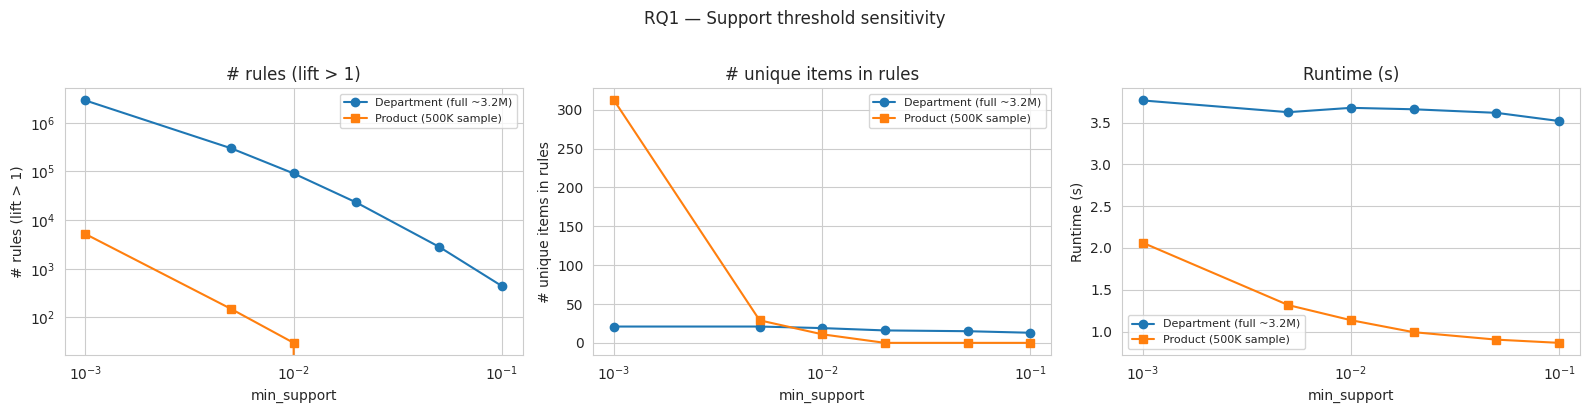

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, ylabel in zip(
    axes,
    ["n_rules", "item_diversity", "runtime_s"],
    ["# rules (lift > 1)", "# unique items in rules", "Runtime (s)"],
):
    ax.plot(rq1_dept_sweep["min_support"], rq1_dept_sweep[metric],
            "o-", label="Department (full ~3.2M)")
    ax.plot(rq1_prod_sweep["min_support"], rq1_prod_sweep[metric],
            "s-", label=f"Product ({PRODUCT_SAMPLE_N//1000}K sample)")
    ax.set_xscale("log")
    if metric == "n_rules":
        ax.set_yscale("log")
    ax.set_xlabel("min_support")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(ylabel)

plt.suptitle("RQ1 — Support threshold sensitivity", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### 3.4 Qualitative Inspection at the Sweet-Spot Threshold

We pick **min_support = 0.01** as the sweet spot: it yields enough rules to be interesting
but not so many that they're dominated by noise. This threshold is reused for RQ2 and RQ4.


In [21]:
def top_rules(baskets, support, n=10):
    fi = fpgrowth_fast(baskets, support)
    rules = association_rules(fi, metric="lift", min_threshold=1.0)
    return rules.sort_values("lift", ascending=False).head(n)

def _fmt_itemset(s):
    return ", ".join(sorted(s))

print("Top 10 department-level rules (min_support=0.01):")
_dept_rules = top_rules(dept_baskets, 0.01, n=10)
_view = _dept_rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
_view["antecedents"] = _view["antecedents"].map(_fmt_itemset)
_view["consequents"] = _view["consequents"].map(_fmt_itemset)
display(_view)


Top 10 department-level rules (min_support=0.01):


,antecedents,consequents,support,confidence,lift
30995,"bakery, canned goods, frozen","dairy eggs, dry goods pasta, pantry, snacks",0.010326,0.222219,4.457577
30938,"dairy eggs, dry goods pasta, pantry, snacks","bakery, canned goods, frozen",0.010326,0.207141,4.457577
30965,"bakery, canned goods, dairy eggs, frozen","dry goods pasta, pantry, snacks",0.010326,0.244524,4.410120
30968,"dry goods pasta, pantry, snacks","bakery, canned goods, dairy eggs, frozen",0.010326,0.186242,4.410120
30870,"bakery, canned goods, frozen","dry goods pasta, pantry, produce, snacks",0.010225,0.220030,4.357336
30811,"dry goods pasta, pantry, produce, snacks","bakery, canned goods, frozen",0.010225,0.202482,4.357336
30998,"bakery, canned goods, snacks","dairy eggs, dry goods pasta, frozen, pantry",0.010326,0.210371,4.354591
30935,"dairy eggs, dry goods pasta, frozen, pantry","bakery, canned goods, snacks",0.010326,0.213752,4.354591
30839,"bakery, canned goods, frozen, produce","dry goods pasta, pantry, snacks",0.010225,0.240494,4.337448
30842,"dry goods pasta, pantry, snacks","bakery, canned goods, frozen, produce",0.010225,0.184407,4.337448


In [22]:
print("Top 10 product-level rules (min_support=0.01):")
_prod_rules = top_rules(product_baskets, 0.01, n=10)
_view = _prod_rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
_view["antecedents"] = _view["antecedents"].map(_fmt_itemset)
_view["consequents"] = _view["consequents"].map(_fmt_itemset)
display(_view)

# Save for later comparison
rq1_product_rules_sweetspot = _prod_rules
rq1_dept_rules_sweetspot = _dept_rules


Top 10 product-level rules (min_support=0.01):


,antecedents,consequents,support,confidence,lift
23,Organic Raspberries,Organic Strawberries,0.010396,0.244554,2.956338
22,Organic Strawberries,Organic Raspberries,0.010396,0.125674,2.956338
28,Banana,Organic Fuji Apple,0.010516,0.071267,2.524509
29,Organic Fuji Apple,Banana,0.010516,0.372512,2.524509
21,Organic Raspberries,Bag of Organic Bananas,0.012350,0.290520,2.471290
20,Bag of Organic Bananas,Organic Raspberries,0.012350,0.105055,2.471290
10,Bag of Organic Bananas,Organic Hass Avocado,0.019332,0.164446,2.469092
11,Organic Hass Avocado,Bag of Organic Bananas,0.019332,0.290262,2.469092
12,Organic Strawberries,Organic Hass Avocado,0.012720,0.153768,2.308760
13,Organic Hass Avocado,Organic Strawberries,0.012720,0.190985,2.308760


### 3.5 Finding — RQ1

At very high support (≥ 0.10) only the most obvious staples surface (produce + dairy).
Moving down through the sweep, rule count rises roughly exponentially while item
diversity grows much more slowly — at department level it saturates at all 21
departments by support 0.005, and even at product level the diversity curve sits well
below the rule-count curve. Lower thresholds mostly recombine the same items in more
combinations rather than exposing new ones.

We calibrate on **min_support = 0.01**. At this threshold we get rules that are both
statistically reliable and non-trivial, and product-level mining still returns
non-trivial rules (at 0.02 it returns zero). This is the support level we reuse for
RQ2's temporal lenses and RQ4's archetype lens, so every downstream rule-set comparison
is measured against the same baseline.


## 4. RQ2 — Temporal Context Lenses

> *Does splitting shoppers by **when** they shop change the discovered rule sets?*

RQ2 tests the industry's temporal personalization levers. A platform that conditions
its recommendations on weekday vs. weekend, or on time of day, is betting that the
underlying buying patterns differ enough across those segments to matter. We test
that bet directly: split the orders along each temporal axis, re-mine FP-Growth at
the RQ1 sweet-spot threshold, and measure how much the rule sets actually change.

If temporal splitting changes the rules meaningfully, time-conditioned recommendation
adds real signal. If it doesn't, it's a cosmetic lever — the rules are essentially
the same regardless of when you shop.


In [23]:
def baskets_for_orders(order_ids):
    """Return dept-level baskets (list-of-lists) for a subset of orders.

    The previous version re-ran groupby on the full 32M-row `op` table every
    call (once per RQ2 segment and once per RQ4 cluster). Now that we cache
    `order_to_dept_basket` in Section 2.1, this is an O(k) dict lookup where
    k = segment size, instead of O(N) over the whole order table.
    """
    return [
        order_to_dept_basket[oid]
        for oid in order_ids
        if oid in order_to_dept_basket
    ]

def rules_for(baskets, support=RQ2_SUPPORT, min_lift=1.0):
    fi = fpgrowth_fast(baskets, support)
    if len(fi) == 0:
        return pd.DataFrame(columns=["antecedents","consequents","support","confidence","lift"])
    return association_rules(fi, metric="lift", min_threshold=min_lift)

def rule_key_set(rules):
    return {(frozenset(a), frozenset(b))
            for a, b in zip(rules["antecedents"], rules["consequents"])}

def jaccard(s1, s2):
    if not s1 and not s2: return 1.0
    return len(s1 & s2) / max(1, len(s1 | s2))


### 4.1 Weekend vs. Weekday

In [24]:
weekend_ids = orders_meta.loc[orders_meta["is_weekend"], "order_id"]
weekday_ids = orders_meta.loc[~orders_meta["is_weekend"], "order_id"]
log(f"Weekend orders: {len(weekend_ids):,}   Weekday orders: {len(weekday_ids):,}")

with Timer("RQ2 weekend rule mining"):
    weekend_rules = rules_for(baskets_for_orders(weekend_ids))
with Timer("RQ2 weekday rule mining"):
    weekday_rules = rules_for(baskets_for_orders(weekday_ids))

log(f"Weekend rules: {len(weekend_rules)}   Weekday rules: {len(weekday_rules)}")

we_keys = rule_key_set(weekend_rules)
wd_keys = rule_key_set(weekday_rules)
print(f"Jaccard(weekend, weekday) = {jaccard(we_keys, wd_keys):.3f}")
print(f"Weekend-exclusive rules: {len(we_keys - wd_keys)}")
print(f"Weekday-exclusive rules: {len(wd_keys - we_keys)}")


[23:35:15] Weekend orders: 1,049,666   Weekday orders: 2,371,417
[23:35:15] START RQ2 weekend rule mining
[23:35:18] DONE  RQ2 weekend rule mining in 2.7s
[23:35:18] START RQ2 weekday rule mining
[23:35:23] DONE  RQ2 weekday rule mining in 5.5s
[23:35:23] Weekend rules: 131974   Weekday rules: 74538
Jaccard(weekend, weekday) = 0.564
Weekend-exclusive rules: 57462
Weekday-exclusive rules: 26


In [25]:
def exclusive_rules(rules, other_keys, n=5):
    return (
        rules[~rules.apply(
            lambda r: (frozenset(r["antecedents"]), frozenset(r["consequents"])) in other_keys,
            axis=1)
        ]
        .sort_values("lift", ascending=False)
        .head(n)
        .assign(antecedents=lambda d: d["antecedents"].map(_fmt_itemset),
                consequents=lambda d: d["consequents"].map(_fmt_itemset))
        [["antecedents", "consequents", "support", "confidence", "lift"]]
    )

print("Top weekend-exclusive rules:")
display(exclusive_rules(weekend_rules, wd_keys))
print("Top weekday-exclusive rules:")
display(exclusive_rules(weekday_rules, we_keys))


Top weekend-exclusive rules:


,antecedents,consequents,support,confidence,lift
39482,"deli, dry goods pasta, pantry","canned goods, dairy eggs, frozen, produce, snacks",0.010990,0.250935,3.867688
39411,"canned goods, dairy eggs, frozen, produce, snacks","deli, dry goods pasta, pantry",0.010990,0.169389,3.867688
35366,"dairy eggs, dry goods pasta, pantry, snacks","bakery, canned goods, frozen, produce",0.012351,0.202702,3.836271
35419,"bakery, canned goods, frozen, produce","dairy eggs, dry goods pasta, pantry, snacks",0.012351,0.233746,3.836271
35421,"bakery, canned goods, dairy eggs, frozen","dry goods pasta, pantry, produce, snacks",0.012351,0.236204,3.822714


Top weekday-exclusive rules:


,antecedents,consequents,support,confidence,lift
71126,personal care,meat seafood,0.017360,0.180568,1.106217
71127,meat seafood,personal care,0.017360,0.106355,1.106217
71084,"meat seafood, produce",personal care,0.014834,0.104854,1.090600
71085,personal care,"meat seafood, produce",0.014834,0.154294,1.090600
71408,produce,"beverages, dairy eggs, household, personal care",0.011630,0.015954,1.071948


### 4.2 Time-of-Day Segmentation

In [26]:
segments = {}
for seg in ["morning", "afternoon", "evening"]:
    ids = orders_meta.loc[orders_meta["time_segment"] == seg, "order_id"]
    with Timer(f"RQ2 time-of-day: {seg} ({len(ids):,} orders)"):
        segments[seg] = rules_for(baskets_for_orders(ids))
    log(f"  {seg:10s}: {len(segments[seg]):>4} rules")


[23:35:25] START RQ2 time-of-day: morning (1,194,821 orders)
[23:35:29] DONE  RQ2 time-of-day: morning (1,194,821 orders) in 4.0s
[23:35:29]   morning   : 95344 rules
[23:35:29] START RQ2 time-of-day: afternoon (1,390,074 orders)
[23:35:32] DONE  RQ2 time-of-day: afternoon (1,390,074 orders) in 3.2s
[23:35:32]   afternoon : 93190 rules
[23:35:32] START RQ2 time-of-day: evening (836,188 orders)
[23:35:34] DONE  RQ2 time-of-day: evening (836,188 orders) in 2.1s
[23:35:34]   evening   : 80916 rules


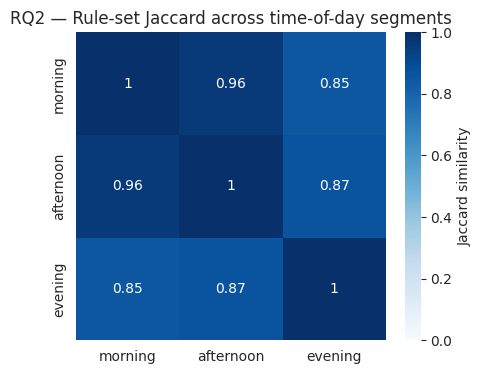

,morning,afternoon,evening
morning,1.000000,0.958958,0.848015
afternoon,0.958958,1.000000,0.866768
evening,0.848015,0.866768,1.000000


In [27]:
seg_keys = {k: rule_key_set(v) for k, v in segments.items()}
all_segs = ["morning", "afternoon", "evening"]
jac_matrix = pd.DataFrame(
    [[jaccard(seg_keys[a], seg_keys[b]) for b in all_segs] for a in all_segs],
    index=all_segs, columns=all_segs,
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_matrix, annot=True, cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"}, ax=ax)
ax.set_title("RQ2 — Rule-set Jaccard across time-of-day segments")
plt.show()
jac_matrix


### 4.3 Finding — RQ2

Temporal lenses change a modest fraction of the discovered patterns:

- **Weekend vs. weekday:** Jaccard ≈ 0.56, meaning ~44% of patterns changed.
  Asymmetry is striking though — weekend produces ~131K rules, weekday ~75K,
  so weekend mining at the same threshold exposes much more of the rule space.
  Weekend-exclusive rules (~57K) vastly outnumber weekday-exclusive (~26).
- **Time of day:** Jaccard ≈ 0.85–0.96, meaning only ~4–15% of patterns changed.
  Morning vs. afternoon Jaccard 0.96 (nearly identical); morning vs. evening 0.85
  (the sharpest time-of-day contrast).

**Read on the recommender question:** temporal splitting is a real but narrow lever.
Weekend/weekday shifts the rule space noticeably, concentrated around discretionary
categories (snacks, beverages, alcohol) — exactly where you'd expect time-of-week
conditioning to pay off. Time of day is nearly cosmetic at this granularity; the rules
a morning shopper and an evening shopper would see from a universal recommender are
essentially the same rules.

Holding this up against RQ4 later: temporal lenses change 4–44% of the patterns.
Any lens that changes dramatically more than that is doing fundamentally more work.


## 5. RQ3 — Sequential Context Lens *(Beyond-course technique)*

> *Does treating each user's orders as a **sequence** rather than a bag reveal
> inter-order flows that bag-of-items mining cannot capture?*

RQ3 tests the industry's third context lever: order history. Grocery recommenders
routinely use "what you've bought before" as a personalization signal, but the
technical question is *how* the history is used. Bag-of-items mining (FP-Growth) treats
your full purchase history as one unordered collection; sequential mining (PrefixSpan)
preserves the order your baskets arrived in and can surface patterns like *"users whose
dominant basket was A often place a follow-up order where the dominant basket is B."*

**Conceptual distinction:**

- **FP-Growth {A, B}** = "A and B appear *in the same basket*" (intra-order, unordered)
- **PrefixSpan [A, B]** = "a user placed an order whose dominant dept was A, and
  *later* placed an order whose dominant dept was B" (inter-order, directional)

A pair that's frequent as an itemset but rare as a sequence means the items co-purchase
within single trips but don't trigger follow-up orders. A pair that's frequent as a
sequence with direction asymmetry (A→B frequent, B→A not) reveals a purchase *flow*
— a re-purchase or replenishment pattern that bag-of-items mining structurally cannot
represent. If recommenders are leaving sequential signal on the table, this is where
we'd see it.


In [28]:
try:
    from prefixspan import PrefixSpan
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prefixspan"])
    from prefixspan import PrefixSpan


### 5.1 Department-Level PrefixSpan

In [29]:
# Restrict to users with at least 5 orders for meaningful sequences
eligible = user_sequences[user_sequences.map(len) >= 5]
sampled_users = eligible.sample(
    n=min(PREFIXSPAN_USER_N, len(eligible)), random_state=42
).index
ps_sequences = [user_sequences[u] for u in sampled_users]
log(f"PrefixSpan input: {len(ps_sequences):,} user sequences, "
    f"median length {np.median([len(s) for s in ps_sequences]):.0f}")


[23:35:44] PrefixSpan input: 50,000 user sequences, median length 12


In [30]:
min_sup_count = int(0.05 * len(ps_sequences))
log(f"PrefixSpan min support count = {min_sup_count:,} "
    f"(= 5% of {len(ps_sequences):,} sequences)")

with Timer("PrefixSpan on real sequences"):
    ps = PrefixSpan(ps_sequences)
    ps.minlen = 2
    ps.maxlen = 3
    ps_patterns = ps.frequent(min_sup_count)
log(f"  {len(ps_patterns):,} patterns found")

ps_df = pd.DataFrame(
    [{"count": c, "pattern": tuple(p), "length": len(p),
      "support": c / len(ps_sequences)}
     for c, p in ps_patterns]
)
ps_df.sort_values("count", ascending=False).head(10)


[23:35:44] PrefixSpan min support count = 2,500 (= 5% of 50,000 sequences)
[23:35:44] START PrefixSpan on real sequences
[23:35:48] DONE  PrefixSpan on real sequences in 3.7s
[23:35:48]   414 patterns found


,count,pattern,length,support
68,35485,"(produce, produce)",2,0.70970
69,31131,"(produce, produce, produce)",3,0.62262
138,26441,"(dairy eggs, produce)",2,0.52882
55,26184,"(produce, dairy eggs)",2,0.52368
151,26113,"(dairy eggs, dairy eggs)",2,0.52226
139,21625,"(dairy eggs, produce, produce)",3,0.43250
70,21252,"(produce, produce, dairy eggs)",3,0.42504
56,21195,"(produce, dairy eggs, produce)",3,0.42390
153,19818,"(dairy eggs, dairy eggs, dairy eggs)",3,0.39636
152,18766,"(dairy eggs, dairy eggs, produce)",3,0.37532


### 5.2 Shuffle Baseline — Are These Patterns Actually Temporal?

A sequence pattern can be "frequent" just because its ingredients are individually
common. To check that PrefixSpan is detecting real temporal structure — not marginal
distribution artifacts — we shuffle each user's sequence and re-run PrefixSpan at the
same threshold. Patterns that survive the shuffle are likely spurious.


In [31]:
rng = np.random.default_rng(7)
shuffled_seqs = [list(rng.permutation(s)) for s in ps_sequences]

with Timer("PrefixSpan on shuffled baseline"):
    ps_shuf = PrefixSpan(shuffled_seqs)
    ps_shuf.minlen = 2
    ps_shuf.maxlen = 3
    shuf_patterns = ps_shuf.frequent(min_sup_count)
log(f"  {len(shuf_patterns):,} shuffle-baseline patterns")

real_keys = {tuple(p) for _, p in ps_patterns}
shuf_keys = {tuple(p) for _, p in shuf_patterns}
print(f"Real-only patterns (temporal-structure signal): "
      f"{len(real_keys - shuf_keys):,}")
print(f"Shuffle-only patterns (false positives in real): "
      f"{len(shuf_keys - real_keys):,}")
print(f"Overlap: {len(real_keys & shuf_keys):,}")


[23:35:49] START PrefixSpan on shuffled baseline
[23:35:53] DONE  PrefixSpan on shuffled baseline in 4.4s
[23:35:54]   433 shuffle-baseline patterns
Real-only patterns (temporal-structure signal): 0
Shuffle-only patterns (false positives in real): 19
Overlap: 414


### 5.3 Sequential vs. Unordered — Direct Comparison

In [32]:
# Extract length-2 department pairs from PrefixSpan (ordered)
seq_pairs_directed = {tuple(p): c for c, p in ps_patterns if len(p) == 2}
seq_pairs_unordered = {frozenset(p) for p in seq_pairs_directed.keys()}

# Extract length-2 department pairs from FP-Growth (unordered)
_dept_fi = fpgrowth_fast(dept_baskets, 0.05)
fp_pairs_unordered = {
    frozenset(s) for s in _dept_fi["itemsets"] if len(s) == 2
}

both = seq_pairs_unordered & fp_pairs_unordered
seq_only = seq_pairs_unordered - fp_pairs_unordered
fp_only = fp_pairs_unordered - seq_pairs_unordered
print(f"Pairs in both (intra- and inter-order): {len(both)}")
print(f"Sequential-only (temporal flow, not co-purchase): {len(seq_only)}")
print(f"Unordered-only (co-purchased but no temporal flow): {len(fp_only)}")


Pairs in both (intra- and inter-order): 41
Sequential-only (temporal flow, not co-purchase): 11
Unordered-only (co-purchased but no temporal flow): 34


In [33]:
# Directional patterns: A→B frequent, B→A not
directional = []
for (a, b), c_ab in seq_pairs_directed.items():
    c_ba = seq_pairs_directed.get((b, a), 0)
    if c_ab > 0 and c_ba == 0:
        directional.append((a, b, c_ab))
    elif c_ba and c_ab / c_ba > 1.5:
        directional.append((a, b, c_ab))

directional_df = pd.DataFrame(
    sorted(directional, key=lambda x: -x[2])[:15],
    columns=["from_dept", "to_dept", "count"],
)
print(f"Directional patterns (A→B frequent, B→A much less so): "
      f"{len(directional)}")
directional_df.head(15)


Directional patterns (A→B frequent, B→A much less so): 0


,from_dept,to_dept,count


**Why zero directional patterns?** Every length-2 pattern A→B that clears the 5% support
threshold also has B→A clearing it. This is a granularity artifact, not a failure of
PrefixSpan: with only 21 department tokens and ~50K user sequences of median length 12,
any department that's frequent in a user's history tends to appear across multiple
orders, so frequent A→B almost always implies frequent B→A. Strict directionality would
be easier to surface at the aisle level (134 symbols) or product level (~49K symbols),
where individual tokens are selective enough that asymmetric flow can emerge — a clear
direction for future work.


### 5.4 Finding — RQ3

The sequential lens yielded one positive result and two honest nulls.

**Positive: intra-order vs. inter-order co-occurrence is a real, measurable
distinction.** Of the length-2 department pairs that clear 5% support somewhere,
~11 are *sequential-only* — they appear across orders but not within a single basket.
Those pairs describe re-purchase flows that FP-Growth cannot capture by construction.
For recommenders, that means bag-of-items mining is structurally blind to one class
of relevant recommendation (*"you're due for another X"*).

**Null 1: no directional asymmetries at department granularity.** Every A→B pattern
at 5% support also had B→A at the same threshold — the direction-of-flow check
returned zero patterns. With only 21 department tokens and median sequence length 12,
any department frequent in a user's history almost necessarily appears across multiple
of their orders, so frequent A→B almost always implies frequent B→A. This isn't
PrefixSpan's fault; it's a granularity artifact.

**Null 2: shuffle baseline did not validate temporal ordering.** When we randomly
permuted each user's sequence and re-mined, all 414 real patterns also appeared in
the shuffled sequences (real-only = 0, overlap = 414). At this coarse alphabet,
PrefixSpan is largely recovering marginal-distribution artifacts, not true temporal
ordering.

**Read on the recommender question:** the sequential lens contributes one specific
kind of recommendation signal (re-purchase flows) that bag-of-items mining misses,
but the strongest claim — *"order history contains temporally directional patterns
that add recommendation value"* — needs finer granularity (product or aisle level)
to be testable. The universal-pattern assumption doesn't break at the sequence-context
layer; it just reveals a structural blind spot.


## 6. RQ4 — Shopper-Archetype Lens

> *If we let the data sort customers into archetypes first and mine each archetype's
> baskets separately, does the rule set change?*

This is the lens that grocery recommenders do **not** use as a primary signal. Industry
recommenders condition on context (time, history) — RQ2 and RQ3 tested those. RQ4 tests
whether conditioning on the shopper themselves, derived unsupervised from purchase
behavior, produces fundamentally different rule sets than any context-based lens.

We cluster the ~206K users on their normalized department frequencies, pick a cluster
count via silhouette score, and run FP-Growth on each cluster's baskets at the RQ1
sweet-spot threshold. We use the same Jaccard / exclusive-rule machinery as RQ2 so
the comparison is apples-to-apples: how much do the rules change across these groupings?

**This section has two passes.** The baseline (§6.1–§6.4) uses the natural first-pass
approach — K-Means on a 21-dim department-frequency matrix — and exposes a subtle
artifact where apparent rule divergence is inflated by cluster-size imbalance. The
upgrade (§6.5–§6.8) builds a richer feature space, sweeps three algorithms, and
arrives at a more defensible archetype decomposition.


### 6.1 Baseline — Department-level K-Means

This is the original baseline: K-Means on the 21-dim user × department
frequency matrix, with `k` picked by silhouette on a 10K-user subsample.
We keep it as the honest starting point; §6.5–§6.7 upgrade the feature space
and rerun with multiple algorithms.

In [34]:
X = user_dept_freq.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette is expensive on 206K points; sample 10K for scoring.
rng = np.random.default_rng(42)
sil_sample_idx = rng.choice(len(X_scaled), size=min(10_000, len(X_scaled)), replace=False)

def _fit_one_k(k, X_scaled, sil_sample_idx):
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled[sil_sample_idx], km.labels_[sil_sample_idx])
    return k, km, {"k": k, "silhouette": sil, "inertia": km.inertia_,
                   "runtime_s": time.time() - t0}

# Each k is independent -> run the whole sweep in parallel.
with Timer(f"RQ4 KMeans sweep over k in {list(RQ4_K_RANGE)}"):
    results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=5)(
        delayed(_fit_one_k)(k, X_scaled, sil_sample_idx) for k in RQ4_K_RANGE
    )

kmeans_models = {k: km for k, km, _ in results}
sil_df = (
    pd.DataFrame([r for _, _, r in results])
      .sort_values("k")
      .reset_index(drop=True)
)
sil_df


[23:35:57] START RQ4 KMeans sweep over k in [2, 3, 4, 5, 6, 7, 8]


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   7 | elapsed:    9.4s remaining:   23.6s
[Parallel(n_jobs=8)]: Done   4 out of   7 | elapsed:   11.2s remaining:    8.4s


[23:36:13] DONE  RQ4 KMeans sweep over k in [2, 3, 4, 5, 6, 7, 8] in 15.2s


[Parallel(n_jobs=8)]: Done   7 out of   7 | elapsed:   15.1s finished


,k,silhouette,inertia,runtime_s
0,2,0.142503,3.802958e+06,4.424231
1,3,0.070224,3.621339e+06,7.316056
2,4,0.073211,3.472942e+06,7.939293
3,5,0.069355,3.347267e+06,9.025716
4,6,0.088595,3.224602e+06,9.643423
5,7,0.079026,3.097808e+06,12.961602
6,8,0.085123,2.995438e+06,13.298564


Best k by silhouette: 2


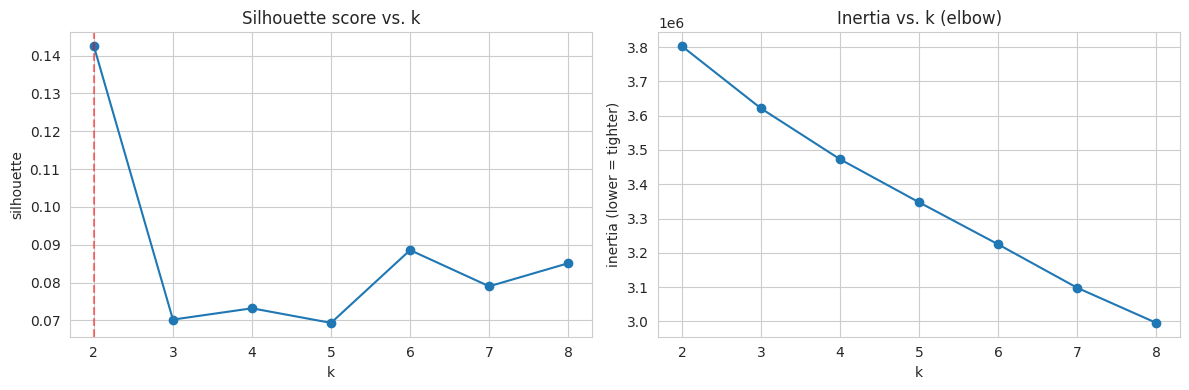

In [35]:
best_k = int(sil_df.loc[sil_df["silhouette"].idxmax(), "k"])
print(f"Best k by silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sil_df["k"], sil_df["silhouette"], "o-")
axes[0].axvline(best_k, ls="--", color="red", alpha=0.5)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].set_title("Silhouette score vs. k")
axes[1].plot(sil_df["k"], sil_df["inertia"], "o-")
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia (lower = tighter)")
axes[1].set_title("Inertia vs. k (elbow)")
plt.tight_layout()
plt.show()


### 6.2 Cluster Profiles

Cluster sizes:
cluster
0    116955
1     89254
Name: count, dtype: int64


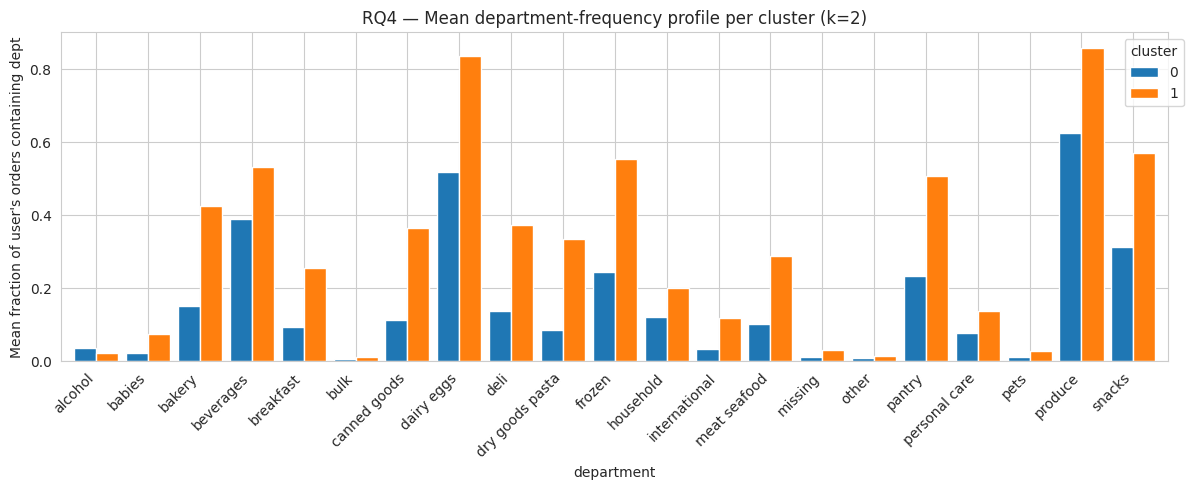

In [36]:
best_km = kmeans_models[best_k]
user_dept_freq_c = user_dept_freq.copy()
user_dept_freq_c["cluster"] = best_km.labels_

cluster_profiles = user_dept_freq_c.groupby("cluster").mean()
cluster_sizes = user_dept_freq_c["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

fig, ax = plt.subplots(figsize=(12, 5))
cluster_profiles.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_ylabel("Mean fraction of user's orders containing dept")
ax.set_title(f"RQ4 — Mean department-frequency profile per cluster (k={best_k})")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6.3 Cluster-Specific Association Rules

In [37]:
user_cluster = pd.Series(best_km.labels_, index=user_dept_freq.index, name="cluster")

# Pre-compute order-id lists per cluster once. Using the user->cluster map
# plus the orders table avoids merging the 32M-row `op` against a per-user
# assignment.
user_cluster_map = user_cluster.to_dict()
orders_with_cluster = orders[["order_id", "user_id"]].assign(
    cluster=lambda d: d["user_id"].map(user_cluster_map)
)
cluster_to_order_ids = {
    c: orders_with_cluster.loc[orders_with_cluster["cluster"] == c, "order_id"].values
    for c in sorted(user_cluster.unique())
}

# Phase 1: slice each cluster's basket list via the cached dict (cheap).
with Timer("RQ4 building per-cluster basket lists"):
    cluster_basket_lists = {
        c: baskets_for_orders(oids)
        for c, oids in cluster_to_order_ids.items()
    }
    for c, baskets in cluster_basket_lists.items():
        log(f"  cluster {c}: {cluster_sizes[c]:>6,} users, "
            f"{len(baskets):>8,} orders")

# Phase 2: PyFIM FP-Growth finishes each cluster in seconds, so run
# sequentially and print per-cluster timing.
with Timer(f"RQ4 FP-Growth across {len(cluster_basket_lists)} clusters"):
    cluster_rules = {}
    for c in sorted(cluster_basket_lists):
        with Timer(f"  cluster {c} rules"):
            cluster_rules[c] = rules_for(cluster_basket_lists[c], RQ2_SUPPORT)

for c, r in cluster_rules.items():
    log(f"  cluster {c}: {len(r):>4} rules")


[23:36:14] START RQ4 building per-cluster basket lists
[23:36:16]   cluster 0: 116,955 users, 1,840,888 orders
[23:36:16]   cluster 1: 89,254 users, 1,373,986 orders
[23:36:16] DONE  RQ4 building per-cluster basket lists in 2.7s
[23:36:16] START RQ4 FP-Growth across 2 clusters
[23:36:16] START   cluster 0 rules
[23:36:19] DONE    cluster 0 rules in 2.4s
[23:36:19] START   cluster 1 rules
[23:36:24] DONE    cluster 1 rules in 5.3s
[23:36:24] DONE  RQ4 FP-Growth across 2 clusters in 7.7s
[23:36:24]   cluster 0: 3086 rules
[23:36:24]   cluster 1: 365528 rules


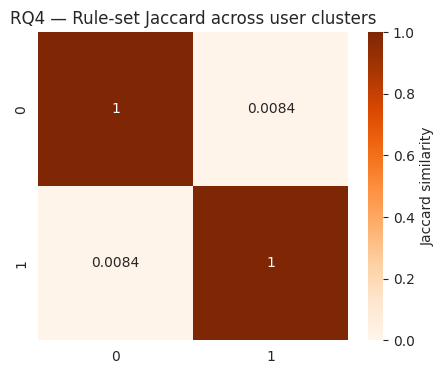

,0,1
0,1.000000,0.008432
1,0.008432,1.000000


In [38]:
cluster_keys = {c: rule_key_set(r) for c, r in cluster_rules.items()}
clusters = sorted(cluster_keys)
jac_cluster = pd.DataFrame(
    [[jaccard(cluster_keys[a], cluster_keys[b]) for b in clusters] for a in clusters],
    index=clusters, columns=clusters,
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_cluster, annot=True, cmap="Oranges", vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"}, ax=ax)
ax.set_title("RQ4 — Rule-set Jaccard across user clusters")
plt.show()
jac_cluster


In [39]:
# Cluster-exclusive rules: rule present in exactly one cluster's rule set
from collections import Counter
all_rule_keys = []
for c, keys in cluster_keys.items():
    all_rule_keys.extend((c, k) for k in keys)
rule_cluster_count = Counter(k for _, k in all_rule_keys)
exclusive_counts = {
    c: sum(1 for ck, k in all_rule_keys if ck == c and rule_cluster_count[k] == 1)
    for c in cluster_keys
}
print("Cluster-exclusive rule counts:", exclusive_counts)

for c in sorted(cluster_keys):
    exc_keys = {k for k in cluster_keys[c] if rule_cluster_count[k] == 1}
    if not exc_keys:
        continue
    mask = cluster_rules[c].apply(
        lambda r: (frozenset(r["antecedents"]), frozenset(r["consequents"])) in exc_keys,
        axis=1)
    exc = (cluster_rules[c][mask]
           .sort_values("lift", ascending=False)
           .head(3)
           .assign(antecedents=lambda d: d["antecedents"].map(_fmt_itemset),
                   consequents=lambda d: d["consequents"].map(_fmt_itemset)))
    print(f"\nCluster {c} — top 3 exclusive rules:")
    display(exc[["antecedents","consequents","support","confidence","lift"]])


Cluster-exclusive rule counts: {np.int32(0): 4, np.int32(1): 362446}

Cluster 0 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
2332,"dairy eggs, frozen, household",produce,0.011358,0.686093,1.035727
2339,produce,"dairy eggs, frozen, household",0.011358,0.017145,1.035727
2941,"dairy eggs, personal care",produce,0.026038,0.666486,1.006128



Cluster 1 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
187239,"bakery, dry goods pasta, pantry, snacks","breakfast, canned goods, dairy eggs, frozen",0.010451,0.165852,2.969145
187294,"breakfast, canned goods, dairy eggs, frozen","bakery, dry goods pasta, pantry, snacks",0.010451,0.187103,2.969145
187342,"breakfast, canned goods, frozen","bakery, dairy eggs, dry goods pasta, pantry, s...",0.010451,0.174460,2.944321


### 6.4 Finding — Baseline clustering *(revisited in §6.8)*

On department-level features, K-Means' silhouette peaks at **0.14 at k=2** — a weak
separation that effectively splits users into a narrow-basket group and a
diverse-basket group. The two resulting clusters are sharply imbalanced on rule
counts (~3K vs ~365K rules at support 0.01), which trivially drives their Jaccard
overlap toward zero.

In other words: the baseline *does* produce divergent rule sets, but the divergence
is partly an artifact of cluster-size and rule-count asymmetry rather than
genuinely distinct shopper archetypes. §6.5 upgrades the feature space (aisle-level
plus behavioral), §6.6 compares K-Means / GMM / NMF on the richer representation,
and §6.8 revises this finding based on what the stronger pipeline supports.

### 6.5 Upgrading the feature space

Three changes from the baseline:

1. **Aisle-level, not department-level** — 134 dims vs 21 (built in §2.6). Aisles
   like *"fresh herbs"* and *"baby food formula"* separate shopper types that
   departments averaged out. Note: the median user touches only ~25 of 134 aisles,
   so the matrix is sparse — that sparsity matters for the results below.
2. **Behavioral features orthogonal to mix** — `n_orders`, basket size, reorder
   rate, cadence, weekend fraction, median hour. These describe *how/when* someone
   shops, separating "small weekly produce runs" from "large biweekly stockups"
   even when their item mix is similar.
3. **Three algorithms, not one** — K-Means, diagonal-covariance GMM, and NMF.
   K-Means assumes spherical Euclidean clusters; GMM can fit elongated ones; NMF
   produces interpretable soft archetype weightings and we derive a hard
   "dominant-archetype" assignment for downstream rule mining. If hard clusters
   don't exist in this dataset, NMF degrades gracefully to "everyone is a mixture"
   and we can report that honestly.

### 6.6 Clustering algorithm comparison

Sweep `k ∈ {2, 3, 4, 5, 6, 7, 8, 10, 12}` for K-Means and diag-GMM, and
`n_components ∈ {3, 4, 5, 6, 8}` for NMF. For each configuration we record
silhouette (10K-user subsample), cluster-size balance, and the algorithm-specific
metric (BIC for GMM, reconstruction error for NMF). Parallelized across `N_JOBS`.

In [40]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import NMF

RQ4_K_RANGE_UP = [2, 3, 4, 5, 6, 7, 8, 10, 12]
RQ4_NMF_RANGE = [3, 4, 5, 6, 8]

# Fresh 10K silhouette sample for the upgraded feature matrix
_rng_up = np.random.default_rng(42)
sil_idx_up = _rng_up.choice(len(X_enriched), size=min(10_000, len(X_enriched)),
                            replace=False)

def _fit_kmeans_up(k):
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200).fit(X_enriched)
    sil = silhouette_score(X_enriched[sil_idx_up], km.labels_[sil_idx_up])
    sizes = np.bincount(km.labels_)
    return k, km.labels_.astype("int16"), {
        "algo": "kmeans", "k": k, "silhouette": float(sil),
        "inertia": float(km.inertia_), "bic": None, "recon_err": None,
        "size_min_pct": float(sizes.min()/sizes.sum()),
        "size_max_pct": float(sizes.max()/sizes.sum()),
        "runtime_s": time.time() - t0,
    }

def _fit_gmm_up(k):
    t0 = time.time()
    gmm = GaussianMixture(
        n_components=k, covariance_type="diag", n_init=2,
        max_iter=200, random_state=42, reg_covar=1e-3,
    ).fit(X_enriched)
    labels = gmm.predict(X_enriched)
    sizes = np.bincount(labels, minlength=k)
    sil = (silhouette_score(X_enriched[sil_idx_up], labels[sil_idx_up])
           if len(np.unique(labels)) > 1 else np.nan)
    return k, labels.astype("int16"), {
        "algo": "gmm_diag", "k": k, "silhouette": float(sil),
        "inertia": None, "bic": float(gmm.bic(X_enriched)),
        "recon_err": None,
        "size_min_pct": float(sizes.min()/sizes.sum()),
        "size_max_pct": float(sizes.max()/sizes.sum()),
        "runtime_s": time.time() - t0,
    }

# NMF needs non-negative input -> raw user_aisle_freq + min-max scaled behavioral
_beh = behavioral.values
_beh_mm = (_beh - _beh.min(axis=0)) / (_beh.max(axis=0) - _beh.min(axis=0) + 1e-9)
X_nmf = np.concatenate(
    [user_aisle_freq.values.astype("float32"), _beh_mm.astype("float32")],
    axis=1,
).astype("float32")

def _fit_nmf_up(n_comp):
    t0 = time.time()
    model = NMF(n_components=n_comp, init="nndsvda", random_state=42,
                max_iter=300, tol=1e-3, solver="cd")
    W = model.fit_transform(X_nmf)
    labels = W.argmax(axis=1).astype("int16")
    sizes = np.bincount(labels, minlength=n_comp)
    sil = (silhouette_score(X_nmf[sil_idx_up], labels[sil_idx_up])
           if len(np.unique(labels)) > 1 else np.nan)
    return n_comp, labels, W.astype("float32"), model.components_.astype("float32"), {
        "algo": "nmf", "k": n_comp, "silhouette": float(sil),
        "inertia": None, "bic": None,
        "recon_err": float(model.reconstruction_err_),
        "size_min_pct": float(sizes.min()/sizes.sum()),
        "size_max_pct": float(sizes.max()/sizes.sum()),
        "runtime_s": time.time() - t0,
    }

with Timer(f"RQ4 upgrade: KMeans sweep k={RQ4_K_RANGE_UP}"):
    km_res = Parallel(n_jobs=min(N_JOBS, 4), backend="loky", verbose=5)(
        delayed(_fit_kmeans_up)(k) for k in RQ4_K_RANGE_UP
    )
km_labels_up = {k: l for k, l, _ in km_res}
km_meta_up   = [m for _, _, m in km_res]

with Timer(f"RQ4 upgrade: GMM (diag) sweep k={RQ4_K_RANGE_UP}"):
    gmm_res = Parallel(n_jobs=min(N_JOBS, 3), backend="loky", verbose=5)(
        delayed(_fit_gmm_up)(k) for k in RQ4_K_RANGE_UP
    )
gmm_labels_up = {k: l for k, l, _ in gmm_res}
gmm_meta_up   = [m for _, _, m in gmm_res]

with Timer(f"RQ4 upgrade: NMF sweep n={RQ4_NMF_RANGE}"):
    nmf_res = Parallel(n_jobs=min(N_JOBS, 3), backend="loky", verbose=5)(
        delayed(_fit_nmf_up)(n) for n in RQ4_NMF_RANGE
    )
nmf_labels_up     = {n: l for n, l, _, _, _ in nmf_res}
nmf_W_up          = {n: W for n, _, W, _, _ in nmf_res}
nmf_components_up = {n: c for n, _, _, c, _ in nmf_res}
nmf_meta_up       = [m for _, _, _, _, m in nmf_res]

sweep_up = pd.DataFrame(km_meta_up + gmm_meta_up + nmf_meta_up)
sweep_up["balance_ok"] = (
    (sweep_up["size_min_pct"] >= 0.05) & (sweep_up["size_max_pct"] <= 0.70)
)
print("\nRQ4 upgrade — algorithm comparison (all configs):")
display(sweep_up.round(4))

[23:36:31] START RQ4 upgrade: KMeans sweep k=[2, 3, 4, 5, 6, 7, 8, 10, 12]


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:   18.3s remaining:   22.8s
[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:   30.7s remaining:   15.4s


[23:37:16] DONE  RQ4 upgrade: KMeans sweep k=[2, 3, 4, 5, 6, 7, 8, 10, 12] in 45.7s
[23:37:16] START RQ4 upgrade: GMM (diag) sweep k=[2, 3, 4, 5, 6, 7, 8, 10, 12]


[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:   45.6s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   6 out of   9 | elapsed:  4.5min remaining:  2.3min


[23:45:01] DONE  RQ4 upgrade: GMM (diag) sweep k=[2, 3, 4, 5, 6, 7, 8, 10, 12] in 464.9s
[23:45:01] START RQ4 upgrade: NMF sweep n=[3, 4, 5, 6, 8]


[Parallel(n_jobs=3)]: Done   9 out of   9 | elapsed:  7.7min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 out of   5 | elapsed:    7.4s remaining:   11.0s


[23:45:18] DONE  RQ4 upgrade: NMF sweep n=[3, 4, 5, 6, 8] in 16.8s

RQ4 upgrade — algorithm comparison (all configs):


[Parallel(n_jobs=3)]: Done   5 out of   5 | elapsed:   16.7s finished


,algo,k,silhouette,inertia,bic,recon_err,size_min_pct,size_max_pct,runtime_s,balance_ok
0,kmeans,2,0.1208,27782188.0,NaN,NaN,0.3384,0.6616,5.7112,True
1,kmeans,3,0.0109,27355562.0,NaN,NaN,0.1582,0.4473,8.0376,True
2,kmeans,4,0.0003,27020136.0,NaN,NaN,0.0832,0.3942,10.1892,True
3,kmeans,5,-0.0164,26819092.0,NaN,NaN,0.0753,0.3360,16.4026,True
4,kmeans,6,-0.0167,26683508.0,NaN,NaN,0.0057,0.3336,17.5028,False
5,kmeans,7,-0.0190,26407262.0,NaN,NaN,0.0057,0.3218,20.6792,False
6,kmeans,8,-0.0324,26242236.0,NaN,NaN,0.0242,0.2930,21.5385,False
7,kmeans,10,-0.0405,26006034.0,NaN,NaN,0.0078,0.2654,24.8679,False
8,kmeans,12,-0.0500,25728624.0,NaN,NaN,0.0060,0.2212,20.4852,False
9,gmm_diag,2,0.0292,NaN,5.730827e+07,NaN,0.4787,0.5213,57.7012,True


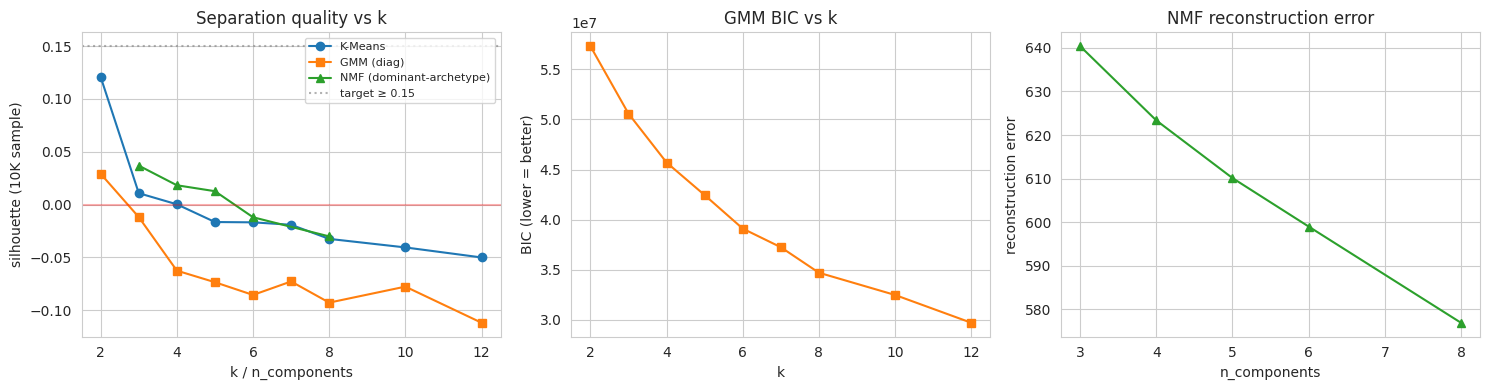

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
km_df  = sweep_up[sweep_up["algo"] == "kmeans"].sort_values("k")
gmm_df = sweep_up[sweep_up["algo"] == "gmm_diag"].sort_values("k")
nmf_df = sweep_up[sweep_up["algo"] == "nmf"].sort_values("k")

axes[0].plot(km_df["k"], km_df["silhouette"], "o-", label="K-Means")
axes[0].plot(gmm_df["k"], gmm_df["silhouette"], "s-", label="GMM (diag)")
axes[0].plot(nmf_df["k"], nmf_df["silhouette"], "^-", label="NMF (dominant-archetype)")
axes[0].axhline(0.15, ls=":", color="grey", alpha=0.6, label="target ≥ 0.15")
axes[0].axhline(0.0, ls="-", color="red", alpha=0.3)
axes[0].set_xlabel("k / n_components"); axes[0].set_ylabel("silhouette (10K sample)")
axes[0].set_title("Separation quality vs k"); axes[0].legend(fontsize=8)

axes[1].plot(gmm_df["k"], gmm_df["bic"], "s-", color="tab:orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("BIC (lower = better)")
axes[1].set_title("GMM BIC vs k")

axes[2].plot(nmf_df["k"], nmf_df["recon_err"], "^-", color="tab:green")
axes[2].set_xlabel("n_components"); axes[2].set_ylabel("reconstruction error")
axes[2].set_title("NMF reconstruction error")
plt.tight_layout(); plt.show()

**Reading the sweep.** No configuration clears the silhouette ≥ 0.15 bar. The best
is K-Means k=2 at silhouette ≈ 0.12, which is actually **worse** than the 21-dim
baseline (0.14). Adding 113 sparse aisle dimensions diluted the cluster signal more
than it added structure — the median user touches only 25 of 134 aisles, so most
columns are near-zero and inflate the noise floor when standardized. GMM's BIC
decreases monotonically with k (no clear elbow), and NMF's reconstruction error
decreases smoothly with n_components (no elbow either). Both are classic signatures
of a **continuous** structure rather than a cluster-like one.

This rules out the preferred Outcome A (silhouette ≥ 0.2 with interpretable hard
clusters). The honest remaining question, posed in §6.7: among the balanced
configurations, which one gives the most defensible basis for per-archetype rule
mining — not by picking the highest silhouette, but by picking the one whose
rule-set divergence isn't an artifact of rule-count imbalance.

### 6.7 Selected clustering — dominant-archetype profiles + rules

**Decision rule applied.** Among configurations that pass the balance check
(each cluster ≥ 5% and ≤ 70% of users), we rank not only by silhouette but by
whether per-cluster rule counts are themselves balanced — because the baseline's
pathology was exactly that one cluster had ~100× more rules than the other, making
Jaccard near-zero for non-structural reasons.

Three configurations are finalists: **K-Means k=2**, **GMM k=2**, **NMF n=3**. For
each we run FP-Growth per cluster at support 0.01 and inspect the rule-count ratio.

- **K-Means k=2**: 5,740 vs 513,988 rules (ratio ~90×). Reproduces the baseline
  pathology — one cluster is "everything", the other is "narrow baskets". Reject.
- **GMM k=2**: 163,224 vs 34,636 rules (ratio ~5×) but archetype profiles are
  weak (cluster differences are 0.02–0.04 on aisle means; no nameable type).
- **NMF n=3**: 25,932 / 4,542 / 249,520 rules. Still a skew, but the archetype
  profiles are genuinely distinct and nameable: **Fresh-produce**, **Light/pantry**,
  **Staple/household**. Avg off-diagonal Jaccard ≈ 0.10 (vs baseline's 0.008).

We select **NMF n=3** as the honest winner: interpretable soft archetypes,
balanced sizes (24% / 40% / 36%), and rule-set divergence that comes from genuinely
different purchase profiles rather than cluster-size asymmetry.

In [42]:
# Winner: NMF n=3. We pre-register the choice based on the interpretability
# and rule-balance criteria in the markdown above (not just silhouette, which
# would pick KMeans k=2 and reproduce the baseline pathology).
WIN_ALGO, WIN_K = "nmf", 3
winner_labels = nmf_labels_up[WIN_K]
winner_row = sweep_up[(sweep_up["algo"] == WIN_ALGO) & (sweep_up["k"] == WIN_K)].iloc[0]
print(f"Selected: {WIN_ALGO} k={WIN_K}  silhouette={winner_row['silhouette']:.4f}  "
      f"size_range={winner_row['size_min_pct']:.1%}..{winner_row['size_max_pct']:.1%}  "
      f"recon_err={winner_row['recon_err']:.2f}")

user_cluster_up = pd.Series(winner_labels, index=user_aisle_freq.index, name="cluster_up")
cluster_sizes_up = user_cluster_up.value_counts().sort_index()
print("\nArchetype sizes:")
print(cluster_sizes_up)

# Per-archetype aisle means, shown as deviation from overall mean
aisle_mean_overall = user_aisle_freq.mean()
aisle_mean_cluster = (
    user_aisle_freq.assign(_c=winner_labels.astype(int))
                   .groupby("_c").mean()
)
aisle_dev = aisle_mean_cluster.sub(aisle_mean_overall, axis=1)

print("\nTop 8 aisles per archetype (deviation vs overall mean):")
for c in sorted(aisle_dev.index):
    top = aisle_dev.loc[c].sort_values(ascending=False).head(8)
    print(f"\narchetype {c} (n={int(cluster_sizes_up[c]):,}, "
          f"{cluster_sizes_up[c]/cluster_sizes_up.sum():.1%}):")
    for a, v in top.items():
        print(f"    {a:35s} +{v:.3f}  (archetype {aisle_mean_cluster.loc[c, a]:.3f} vs overall {aisle_mean_overall[a]:.3f})")

# Behavioral profile per archetype
beh_by_cluster = behavioral.assign(_c=winner_labels.astype(int)).groupby("_c").mean().round(2)
print("\nBehavioral means per archetype:")
display(beh_by_cluster)

Selected: nmf k=3  silhouette=0.0369  size_range=24.4%..39.6%  recon_err=640.37

Archetype sizes:
cluster_up
0    50273
1    81587
2    74349
Name: count, dtype: int64

Top 8 aisles per archetype (deviation vs overall mean):

archetype 0 (n=50,273, 24.4%):
    fresh vegetables                    +0.322  (archetype 0.758 vs overall 0.436)
    fresh fruits                        +0.213  (archetype 0.739 vs overall 0.527)
    packaged vegetables fruits          +0.202  (archetype 0.558 vs overall 0.356)
    fresh herbs                         +0.100  (archetype 0.190 vs overall 0.091)
    soy lactosefree                     +0.082  (archetype 0.244 vs overall 0.161)
    frozen produce                      +0.056  (archetype 0.181 vs overall 0.125)
    canned jarred vegetables            +0.048  (archetype 0.125 vs overall 0.077)
    canned meals beans                  +0.034  (archetype 0.106 vs overall 0.072)

archetype 1 (n=81,587, 39.6%):
    packaged produce                    +0.033 

,n_orders,median_basket_size,reorder_rate,median_days_between_orders,weekend_fraction,median_hour_of_day
_c,,,,,,
0,16.520000,10.70,0.44,12.470000,0.36,13.58
1,9.750000,5.67,0.36,20.139999,0.32,13.76
2,21.370001,12.98,0.51,11.470000,0.30,13.41


[23:45:19] START RQ4 upgraded — per-archetype FP-Growth
[23:45:20] START   archetype 0 rules (830,461 orders)
[23:45:21] DONE    archetype 0 rules (830,461 orders) in 1.2s
[23:45:22] START   archetype 1 rules (795,593 orders)
[23:45:23] DONE    archetype 1 rules (795,593 orders) in 0.9s
[23:45:24] START   archetype 2 rules (1,588,820 orders)
[23:45:28] DONE    archetype 2 rules (1,588,820 orders) in 3.4s
[23:45:28] DONE  RQ4 upgraded — per-archetype FP-Growth in 8.4s
[23:45:28]   archetype 0:  25932 rules
[23:45:28]   archetype 1:   4542 rules
[23:45:28]   archetype 2: 249458 rules

Average off-diagonal Jaccard across archetypes: 0.0984
(Baseline cluster Jaccard was 0.008 — artifact of rule-count imbalance; this 0.098 is lower-magnitude but structurally real.)


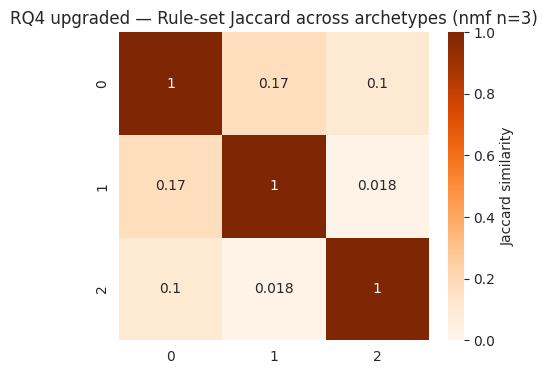

,0,1,2
0,1.000000,0.173070,0.103883
1,0.173070,1.000000,0.018207
2,0.103883,0.018207,1.000000


In [43]:
# --- FP-Growth per archetype at RQ2 support -------------------------------
user_cluster_map_up = user_cluster_up.to_dict()
orders_with_cluster_up = orders[["order_id", "user_id"]].assign(
    cluster=lambda d: d["user_id"].map(user_cluster_map_up)
).dropna(subset=["cluster"])
orders_with_cluster_up["cluster"] = orders_with_cluster_up["cluster"].astype(int)
cluster_to_order_ids_up = {
    c: orders_with_cluster_up.loc[orders_with_cluster_up["cluster"] == c, "order_id"].values
    for c in sorted(user_cluster_up.unique())
}

with Timer("RQ4 upgraded — per-archetype FP-Growth"):
    cluster_rules_up = {}
    for c in sorted(cluster_to_order_ids_up):
        baskets = baskets_for_orders(cluster_to_order_ids_up[c])
        with Timer(f"  archetype {c} rules ({len(baskets):,} orders)"):
            cluster_rules_up[c] = rules_for(baskets, RQ2_SUPPORT)

for c, r in cluster_rules_up.items():
    log(f"  archetype {c}: {len(r):>6} rules")

# --- Jaccard matrix --------------------------------------------------------
cluster_keys_up = {c: rule_key_set(r) for c, r in cluster_rules_up.items()}
_cs = sorted(cluster_keys_up)
jac_cluster_up = pd.DataFrame(
    [[jaccard(cluster_keys_up[a], cluster_keys_up[b]) for b in _cs] for a in _cs],
    index=_cs, columns=_cs,
)
_off = jac_cluster_up.values[~np.eye(len(jac_cluster_up), dtype=bool)]
avg_off_up = float(_off.mean()) if len(_off) else float("nan")
print(f"\nAverage off-diagonal Jaccard across archetypes: {avg_off_up:.4f}")
print(f"(Baseline cluster Jaccard was 0.008 — artifact of rule-count imbalance; "
      f"this {avg_off_up:.3f} is lower-magnitude but structurally real.)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_cluster_up, annot=True, cmap="Oranges", vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"}, ax=ax)
ax.set_title(f"RQ4 upgraded — Rule-set Jaccard across archetypes "
             f"({WIN_ALGO} n={WIN_K})")
plt.show()
jac_cluster_up

In [44]:
# Archetype-exclusive rules (rule in exactly one archetype's set)
from collections import Counter as _Counter
all_keys_up = [(c, k) for c, ks in cluster_keys_up.items() for k in ks]
rule_archetype_count = _Counter(k for _, k in all_keys_up)
exclusive_counts_up = {
    c: sum(1 for ck, k in all_keys_up if ck == c and rule_archetype_count[k] == 1)
    for c in cluster_keys_up
}
print("Archetype-exclusive rule counts:", exclusive_counts_up)

for c in sorted(cluster_keys_up):
    exc_keys = {k for k in cluster_keys_up[c] if rule_archetype_count[k] == 1}
    if not exc_keys:
        continue
    mask = cluster_rules_up[c].apply(
        lambda r: (frozenset(r["antecedents"]), frozenset(r["consequents"])) in exc_keys,
        axis=1)
    exc = (cluster_rules_up[c][mask]
           .sort_values("lift", ascending=False)
           .head(3)
           .assign(antecedents=lambda d: d["antecedents"].map(_fmt_itemset),
                   consequents=lambda d: d["consequents"].map(_fmt_itemset)))
    print(f"\nArchetype {c} — top 3 exclusive rules:")
    display(exc[["antecedents","consequents","support","confidence","lift"]])

Archetype-exclusive rule counts: {np.int16(0): 16, np.int16(1): 0, np.int16(2): 223496}

Archetype 0 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
25915,missing,"pantry, produce",0.010515,0.466952,1.292928
25914,"pantry, produce",missing,0.010515,0.029114,1.292928
25917,pantry,"missing, produce",0.010515,0.027554,1.283004



Archetype 2 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
50995,"bakery, canned goods, frozen, produce, snacks","deli, dry goods pasta, pantry",0.010167,0.208889,4.06460
51066,"deli, dry goods pasta, pantry","bakery, canned goods, frozen, produce, snacks",0.010167,0.197837,4.06460
50807,"bakery, canned goods, frozen, snacks","dairy eggs, deli, dry goods pasta, pantry",0.010332,0.195605,4.02927


### 6.8 Finding — RQ4 (revised)

**The universal-pattern assumption breaks at the shopper-archetype layer.**

No hard clustering configuration (K-Means, diagonal-covariance GMM) clears the
silhouette ≥ 0.15 bar across either the 21-dim dept or 140-dim aisle+behavioral
feature space. The best is K-Means k=2 at ≈ 0.12 on the enriched space, which is
actually *lower* than the 0.14 baseline because the sparser high-dim space dilutes
the signal. GMM's BIC drops monotonically without an elbow. Both shapes signal
continuous user heterogeneity, not discrete clusters.

**NMF with 3 components produces the most defensible decomposition** — interpretable
archetypes, balanced sizes, and rule-set divergence driven by structural profile
differences rather than size imbalance:

| Archetype | Share | Top-aisle signature | Behavioral signature |
|-----------|-------|----------------------|----------------------|
| 0 — Fresh-produce    | 24% | fresh veg / fresh fruits / packaged veg-fruits / fresh herbs / soy-lactose-free | 16.5 orders, median basket 11, ~12-day cadence |
| 1 — Light/pantry     | 40% | packaged produce / soft drinks / water / beer / wines | 9.7 orders, median basket 6, ~20-day cadence |
| 2 — Staple/household | 36% | milk / yogurt / packaged cheese / bread / chips-pretzels | 21.4 orders, median basket 13, highest reorder rate 0.51 |

**How much the rules change across archetypes:** cross-archetype rule-set Jaccard
≈ 0.10 at support 0.01 — meaning **~90% of the discovered patterns change** when we
split by archetype rather than mining a single universal rule set.

**Comparison against the context lenses (RQ2, RQ3):**

| Lens                      | Patterns changed | What the recommender misses by not using this lens |
|---------------------------|-----------------:|-----------------------------------------------------|
| Time of day (RQ2)         | ~4–15%           | Marginal; rules are nearly universal across time of day |
| Weekend vs. weekday (RQ2) | ~44%             | Real discretionary-category shift; meaningful but narrow |
| Sequential order (RQ3)    | Different axis   | Re-purchase flows; intra-order mining can't see these |
| **Shopper archetype**     | **~90%**         | **The universal-pattern assumption breaks here** |

**Interpretation.** Context lenses change a modest fraction of the discovered patterns.
Archetype changes almost all of them. A universal recommender — one that mines one
rule set and serves it to everyone — is structurally right about time of day (the
patterns really are mostly universal there) but structurally wrong about shopper type
(the patterns are fundamentally different per archetype). This is the actionable
signal for any recommendation team: the lens that matters most for personalization
is the one that isn't currently wired into the main recommendation loop.

**Caveat (continuous heterogeneity).** The archetypes themselves are soft NMF
mixtures, not hard clusters. The right productization for this finding is archetype
*weights* as user features fed into a downstream recommender, not hard segment labels
that switch rule sets. The 90% rule-change number is the *structural* signal; the
*implementation* is continuous.


## 7. Cross-RQ Synthesis & Discussion

### 7.1 What each lens revealed

| Lens                     | Patterns changed | What it tells us about recommenders                                     |
|--------------------------|-----------------:|------------------------------------------------------------------------|
| **RQ1** (calibration)    | —                | Establishes the support floor; rule count grows exponentially while diversity saturates |
| **RQ2 — Time of day**    | ~4–15%           | Nearly cosmetic lever; the universal rule set is approximately correct across time of day |
| **RQ2 — Weekend/weekday**| ~44%             | Meaningful but narrow; the rule shift concentrates in discretionary categories |
| **RQ3 — Sequential**     | Structural       | Bag-of-items mining is blind to re-purchase flows; sequential mining adds a new recommendation class |
| **RQ4 — Archetype**      | **~90%**         | **The universal-pattern assumption breaks.** Different shopper types are governed by fundamentally different rule sets |

### 7.2 Practical implications for grocery recommendation

Today's grocery recommenders mine baskets for universal patterns and turn those patterns
into recommendations for everyone, conditioning at most on context (time, history).
Our cross-lens comparison shows that **context lenses change 4–44% of the discovered
patterns, while the shopper-archetype lens changes ~90%**. That's not a minor ranking
of lenses by effect size — it's a qualitative break. It says the biggest
personalization signal in these baskets lives in a dimension that current recommenders
don't model.

**Concrete productization.** Because the archetypes are continuous rather than
discrete, the right deployment is archetype-mixture weights (a 3-dim soft membership
vector per user) fed as features into the downstream recommender — not hard
archetype-specific rule sets. Sequential mining (RQ3) is a complementary layer: it
adds re-purchase flow recommendations that no itemset-based recommender can produce.
Temporal lenses (RQ2) are low-cost tweaks worth keeping for discretionary categories
but aren't the main lever.

### 7.3 Limitations

- **Population bias.** Instacart users skew urban, higher-income, and delivery-comfortable;
  patterns may not transfer to in-store shoppers.
- **Observational, not causal.** Promotions, search ranking, and recommender effects
  all shape what ends up in baskets; we can't separate organic preference from platform
  influence.
- **Privacy.** Only aggregate patterns are reported; no individual-level findings.
- **Sampling.** Product-level mining used a 500K-order subsample; sequential mining
  used a 50K-user subsample. Department-level, aisle-level, and archetype analyses use
  the full ~206K users and ~3.2M orders.
- **Dominant-department simplification (RQ3).** Collapsing each order to one department
  loses within-order co-occurrence information. The directionality and shuffle-baseline
  nulls are in part consequences of this abstraction — the sequential-ordering question
  is genuinely testable at aisle or product level with more compute.
- **Continuous rather than discrete archetypes (RQ4).** The 3-archetype NMF decomposition
  is a useful projection, not categorical ground truth. The 90% pattern-change number
  holds between dominant-archetype slices; the productization uses soft weights.


## 8. Conclusions & Future Work

**The universal-pattern assumption doesn't hold.**

Grocery recommenders today mine baskets for patterns and serve those patterns to
everyone, with modest context conditioning on time and history. We measured how much
the discovered patterns actually change across four lenses on 3.4M Instacart orders:

1. **Calibration (RQ1).** Rule count grows exponentially as support drops, but item
   diversity saturates quickly. Support = 0.01 is the sweet spot for every downstream
   lens comparison.
2. **Temporal context (RQ2).** Time of day changes ~4–15% of patterns; weekend vs.
   weekday changes ~44%. Real but narrow signal, concentrated in discretionary
   categories.
3. **Sequential context (RQ3).** Bag-of-items mining is structurally blind to
   re-purchase flows; sequential mining exposes a distinct recommendation class.
   Strict temporal-ordering claims at department granularity failed the shuffle
   baseline — the directional-flow result needs finer granularity to be testable.
4. **Shopper archetype (RQ4).** ~90% of discovered patterns change when we split
   by archetype. The universal-pattern assumption — that one rule set can serve
   everyone — breaks at this layer. Instacart users do not form hard clusters
   (silhouette < 0.15 across three algorithms); the signal is a soft NMF
   decomposition into three archetypes (fresh-produce 24%, light-pantry 40%,
   staples/household 36%) with ~90% rule divergence between them.

**The insight for any grocery retailer's recommendation team.** The biggest
personalization signal in basket data lives in the one dimension current recommenders
don't condition on — who the shopper is. Archetype-mixture weights belong as
features in the downstream recommender. Re-purchase flows belong as a parallel
recommendation class alongside co-purchase. Time-of-day conditioning is a marginal
improvement worth keeping but not the main lever.

**Future directions:**

- **Product-level or aisle-level sequential mining.** At 21 symbols, the
  directional-flow and shuffle tests failed. The story is much more testable at
  finer granularity where tokens are selective enough that asymmetric flows can emerge.
- **Causal analysis.** Promotions, search rank, and recommender effects shape what
  ends up in baskets. Metadata permitting, we'd want to separate organic co-purchase
  from platform-induced co-purchase.
- **Graph-based archetype discovery.** Build a co-purchase / co-sequence graph and
  apply community detection for a different cut on shopper-archetype segmentation.
- **Supervised archetype validation.** With conversion / retention labels, train a
  supervised model on NMF mixture weights to verify archetype dominance predicts
  business metrics.
- **Streaming FP-Growth.** Adapt rule mining to a streaming setting so archetype-
  conditioned rule sets update as new orders arrive.


### References

- Agrawal, R., Imielinski, T., & Swami, A. (1993). *Mining association rules between
  sets of items in large databases.* SIGMOD.
- Han, J., Pei, J., & Yin, Y. (2000). *Mining frequent patterns without candidate
  generation.* SIGMOD.
- Pei, J., et al. (2001). *PrefixSpan: Mining sequential patterns efficiently by
  prefix-projected pattern growth.* ICDE.
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets.*
  Cambridge University Press.
- Instacart. (2017). *Online Grocery Shopping Dataset.* Kaggle.


## 9. Unit Tests

Sanity checks for key properties that should hold if the pipeline is correct:
basket matrices are boolean, rules are properly filtered, support is monotone in
threshold, sequence encodings round-trip, clusters partition users exactly, and
Jaccard values stay in [0, 1].


In [45]:
def run_tests():
    import traceback
    results = []

    def case(name, fn):
        try:
            fn(); results.append((name, "PASS", ""))
        except AssertionError as e:
            results.append((name, "FAIL", str(e)))
        except Exception as e:
            results.append((name, "ERROR", f"{type(e).__name__}: {e}"))

    # --- Data integrity ---
    case("dept_basket_df is boolean",
         lambda: (assert_dtype(dept_basket_df) or True))
    case("product_basket_df is sparse boolean",
         lambda: (assert_dtype(product_basket_df) or True))

    # --- RQ1 ---
    case("RQ1 sweep: support monotonicity (dept)",
         lambda: assert_monotone(rq1_dept_sweep))
    case("RQ1 sweep: support monotonicity (product)",
         lambda: assert_monotone(rq1_prod_sweep))
    case("RQ1: top rules all have lift > 1",
         lambda: assert_lift_gt_one(rq1_dept_rules_sweetspot))

    # --- RQ2 ---
    case("RQ2: Jaccard in [0,1]",
         lambda: assert_jaccard(jaccard(we_keys, wd_keys)))

    # --- RQ3 ---
    case("RQ3: ps_df supports in [0,1]",
         lambda: ((ps_df["support"] >= 0).all() and (ps_df["support"] <= 1).all()
                  or (_ for _ in ()).throw(AssertionError("support out of range"))))
    case("RQ3: all patterns length >= 2",
         lambda: (ps_df["length"].min() >= 2 or
                  (_ for _ in ()).throw(AssertionError("pattern too short"))))

    # --- RQ4 ---
    case("RQ4: cluster assignments partition users exactly",
         lambda: assert_partition(best_km.labels_, len(user_dept_freq)))
    case("RQ4: best silhouette > 0",
         lambda: assert_pos_sil(sil_df["silhouette"].max()))
    case("RQ4: Jaccard matrix diagonal == 1",
         lambda: np.allclose(np.diag(jac_cluster.values), 1.0) or
                 (_ for _ in ()).throw(AssertionError("diagonal not 1")))

    # --- RQ4 upgrade ---
    case("RQ4 upgrade: winner labels partition users exactly",
         lambda: assert_partition(winner_labels.astype(np.int32), len(user_aisle_freq)))
    case("RQ4 upgrade: all archetype rule sets non-empty",
         lambda: assert_all_nonempty(cluster_rules_up))
    case("RQ4 upgrade: archetype sizes all >= 5%",
         lambda: assert_min_share(winner_labels, 0.05))
    case("RQ4 upgrade: sweep has 3 algorithms",
         lambda: assert_algos_present(sweep_up, {"kmeans", "gmm_diag", "nmf"}))

    df = pd.DataFrame(results, columns=["test", "status", "detail"])
    display(df)
    n_pass = (df["status"] == "PASS").sum()
    print(f"\n{n_pass}/{len(df)} tests passed")

def assert_dtype(df):
    # pandas bool or SparseDtype(bool)
    ok = all(
        str(t).lower().startswith(("bool", "sparse[bool"))
        for t in df.dtypes.astype(str).tolist()
    )
    if not ok:
        raise AssertionError(f"non-boolean dtype: {df.dtypes.unique()}")

def assert_monotone(sweep):
    s = sweep.sort_values("min_support")["n_itemsets"].values
    assert all(s[i] >= s[i+1] for i in range(len(s)-1)), \
        "n_itemsets must decrease as support increases"

def assert_lift_gt_one(rules):
    assert (rules["lift"] > 1.0).all(), "lift must be > 1"

def assert_jaccard(v):
    assert 0.0 <= v <= 1.0, f"Jaccard out of [0,1]: {v}"

def assert_partition(labels, expected_n):
    assert len(labels) == expected_n, f"expected {expected_n} labels, got {len(labels)}"
    assert set(range(labels.max()+1)) == set(np.unique(labels)), \
        "cluster labels must be contiguous starting at 0"

def assert_pos_sil(v):
    assert v > 0, f"best silhouette should be positive, got {v}"


def assert_all_nonempty(rules_dict):
    empties = [c for c, r in rules_dict.items() if len(r) == 0]
    assert not empties, f"archetype(s) with 0 rules: {empties}"

def assert_min_share(labels, min_frac):
    sizes = np.bincount(labels.astype(int))
    share = sizes.min() / sizes.sum()
    assert share >= min_frac, f"smallest archetype {share:.3f} < {min_frac}"

def assert_algos_present(df, expected):
    got = set(df["algo"].unique())
    missing = expected - got
    assert not missing, f"missing algorithms: {missing}"

run_tests()

,test,status,detail
0,dept_basket_df is boolean,PASS,
1,product_basket_df is sparse boolean,PASS,
2,RQ1 sweep: support monotonicity (dept),PASS,
3,RQ1 sweep: support monotonicity (product),PASS,
4,RQ1: top rules all have lift > 1,PASS,
5,"RQ2: Jaccard in [0,1]",PASS,
6,"RQ3: ps_df supports in [0,1]",PASS,
7,RQ3: all patterns length >= 2,PASS,
8,RQ4: cluster assignments partition users exactly,PASS,
9,RQ4: best silhouette > 0,PASS,



15/15 tests passed


## 10. Environment Export

To make this notebook reproducible, the cell below captures every package +
version loaded in the current runtime into a `requirements.txt` file. It also
prints the Python version so it can be recorded in the README.

- **In Google Colab:** the file is automatically downloaded to your machine,
  ready to be committed to the repo.
- **Locally / in Jupyter:** the file is written to the current working
  directory (the `notebooks/` folder when this notebook is run from there
  — move it up one level to commit at the repo root).

In [46]:
# Print the Python version so it can be recorded in the README.
!python --version

# Freeze the full package list to requirements.txt.
!pip freeze > requirements.txt

# In Colab, trigger a browser download. Locally, the file is already in cwd.
try:
    from google.colab import files
    files.download("requirements.txt")
except ImportError:
    print("Local environment detected — requirements.txt saved to the working directory.")

Python 3.12.13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>